<a href="https://www.kaggle.com/code/lalit7881/food-delivery-time-prediction-94-72?scriptVersionId=342304458" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dharmendrapandit12/food-delivery-time-prediction-dataset/Food_Delivery_Time_Prediction.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/dharmendrapandit12/food-delivery-time-prediction-dataset/Food_Delivery_Time_Prediction.csv")

In [3]:
df.head()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,...,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,...,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,...,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,...,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,...,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75


In [4]:
df.tail()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
49995,ORD049996,2025-03-08,14,Saturday,1,0,Fog,Industrial,Industrial,Electric Scooter,...,1,Medium,25,33.67,Long,Low,4,28.6,Normal,94
49996,ORD049997,2025-10-23,8,Thursday,0,0,Clear,Suburban,Residential,Bike,...,4,Medium,35,15.92,Long,Low,5,44.0,Normal,54
49997,ORD049998,2025-10-24,7,Friday,0,0,Storm,Residential,CBD,Scooter,...,1,Low,9,19.38,Long,Low,9,23.7,Normal,66
49998,ORD049999,2025-03-16,20,Sunday,1,0,Clear,Residential,CBD,Scooter,...,2,Medium,26,30.92,Long,Moderate,7,28.4,Priority,92
49999,ORD050000,2025-10-21,21,Tuesday,0,0,Rain,Residential,Residential,Bike,...,3,Low,24,35.51,Long,Moderate,8,29.5,Normal,103


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Order_ID                    50000 non-null  object 
 1   Order_Date                  50000 non-null  object 
 2   Order_Hour                  50000 non-null  int64  
 3   Day_of_Week                 50000 non-null  object 
 4   Is_Weekend                  50000 non-null  int64  
 5   Is_Festival                 50000 non-null  int64  
 6   Weather                     50000 non-null  object 
 7   Pickup_Zone                 50000 non-null  object 
 8   Dropoff_Zone                50000 non-null  object 
 9   Vehicle_Type                50000 non-null  object 
 10  Rider_Experience_Years      50000 non-null  float64
 11  Rider_Rating                50000 non-null  float64
 12  Restaurant_Rating           50000 non-null  float64
 13  Cuisine_Type                500

In [6]:
df.describe()

,Order_Hour,Is_Weekend,Is_Festival,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Order_Items,Preparation_Time_Min,Road_Distance_km,Number_of_Signals,Average_Speed_kmph,Time_taken_min
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,13.847700,0.283600,0.049100,4.439744,3.951646,4.175368,2.652740,24.03118,26.201744,9.728920,31.759634,83.868980
std,5.525291,0.450749,0.216079,2.927752,0.294960,0.356201,1.590359,8.34877,12.620079,4.330849,9.510842,35.426899
min,0.000000,0.000000,0.000000,0.100000,3.200000,3.300000,1.000000,5.00000,0.080000,2.000000,8.000000,10.000000
25%,10.000000,0.000000,0.000000,2.200000,3.700000,3.900000,1.000000,18.00000,16.330000,6.000000,25.300000,58.000000
50%,14.000000,0.000000,0.000000,3.800000,3.900000,4.200000,2.000000,24.00000,25.620000,9.000000,33.100000,78.000000
75%,19.000000,1.000000,0.000000,5.900000,4.100000,4.400000,4.000000,30.00000,35.480000,14.000000,39.600000,102.000000
max,23.000000,1.000000,1.000000,15.000000,5.000000,5.000000,7.000000,51.00000,70.820000,18.000000,48.300000,180.000000


In [7]:

df.isnull()

,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,...,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Order_ID                      0
Order_Date                    0
Order_Hour                    0
Day_of_Week                   0
Is_Weekend                    0
Is_Festival                   0
Weather                       0
Pickup_Zone                   0
Dropoff_Zone                  0
Vehicle_Type                  0
Rider_Experience_Years        0
Rider_Rating                  0
Restaurant_Rating             0
Cuisine_Type                  0
Order_Items                   0
Restaurant_Load               0
Preparation_Time_Min          0
Road_Distance_km              0
Delivery_Distance_Category    0
Traffic_Level                 0
Number_of_Signals             0
Average_Speed_kmph            0
Delivery_Priority             0
Time_taken_min                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Order_ID                       object
Order_Date                     object
Order_Hour                      int64
Day_of_Week                    object
Is_Weekend                      int64
Is_Festival                     int64
Weather                        object
Pickup_Zone                    object
Dropoff_Zone                   object
Vehicle_Type                   object
Rider_Experience_Years        float64
Rider_Rating                  float64
Restaurant_Rating             float64
Cuisine_Type                   object
Order_Items                     int64
Restaurant_Load                object
Preparation_Time_Min            int64
Road_Distance_km              float64
Delivery_Distance_Category     object
Traffic_Level                  object
Number_of_Signals               int64
Average_Speed_kmph            float64
Delivery_Priority              object
Time_taken_min                  int64
dtype: object

In [11]:
df.shape

(50000, 24)

In [12]:
df.columns

Index(['Order_ID', 'Order_Date', 'Order_Hour', 'Day_of_Week', 'Is_Weekend',
       'Is_Festival', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type',
       'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating',
       'Cuisine_Type', 'Order_Items', 'Restaurant_Load',
       'Preparation_Time_Min', 'Road_Distance_km',
       'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals',
       'Average_Speed_kmph', 'Delivery_Priority', 'Time_taken_min'],
      dtype='object')

In [13]:
df.nunique()

Order_ID                      50000
Order_Date                      365
Order_Hour                       24
Day_of_Week                       7
Is_Weekend                        2
Is_Festival                       2
Weather                           5
Pickup_Zone                       5
Dropoff_Zone                      5
Vehicle_Type                      4
Rider_Experience_Years          129
Rider_Rating                     19
Restaurant_Rating                18
Cuisine_Type                      9
Order_Items                       7
Restaurant_Load                   3
Preparation_Time_Min             47
Road_Distance_km               5674
Delivery_Distance_Category        3
Traffic_Level                     4
Number_of_Signals                17
Average_Speed_kmph              393
Delivery_Priority                 3
Time_taken_min                  170
dtype: int64

## EDA

DATASET SHAPE
(50000, 24)

COLUMNS
Index(['Order_ID', 'Order_Date', 'Order_Hour', 'Day_of_Week', 'Is_Weekend',
       'Is_Festival', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type',
       'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating',
       'Cuisine_Type', 'Order_Items', 'Restaurant_Load',
       'Preparation_Time_Min', 'Road_Distance_km',
       'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals',
       'Average_Speed_kmph', 'Delivery_Priority', 'Time_taken_min'],
      dtype='object')

FIRST 5 ROWS


,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Cuisine_Type,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,3.8,Pizza,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,3.9,Desserts,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,4.0,Biryani,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,4.6,Burger,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,4.0,Desserts,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75



DATA TYPES
Order_ID                       object
Order_Date                     object
Order_Hour                      int64
Day_of_Week                    object
Is_Weekend                      int64
Is_Festival                     int64
Weather                        object
Pickup_Zone                    object
Dropoff_Zone                   object
Vehicle_Type                   object
Rider_Experience_Years        float64
Rider_Rating                  float64
Restaurant_Rating             float64
Cuisine_Type                   object
Order_Items                     int64
Restaurant_Load                object
Preparation_Time_Min            int64
Road_Distance_km              float64
Delivery_Distance_Category     object
Traffic_Level                  object
Number_of_Signals               int64
Average_Speed_kmph            float64
Delivery_Priority              object
Time_taken_min                  int64
dtype: object

MISSING VALUES
Order_ID                      0
Order_Date    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,50000,50000,ORD049984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,50000,365,2025-02-12,170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Hour,50000.0,NaN,NaN,NaN,13.8477,5.525291,0.0,10.0,14.0,19.0,23.0
Day_of_Week,50000,7,Tuesday,7264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Is_Weekend,50000.0,NaN,NaN,NaN,0.2836,0.450749,0.0,0.0,0.0,1.0,1.0
Is_Festival,50000.0,NaN,NaN,NaN,0.0491,0.216079,0.0,0.0,0.0,0.0,1.0
Weather,50000,5,Clear,23992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup_Zone,50000,5,Residential,15786,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dropoff_Zone,50000,5,Residential,16106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vehicle_Type,50000,4,Bike,22943,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Order Date Range:
2025-01-01 00:00:00
2025-12-31 00:00:00


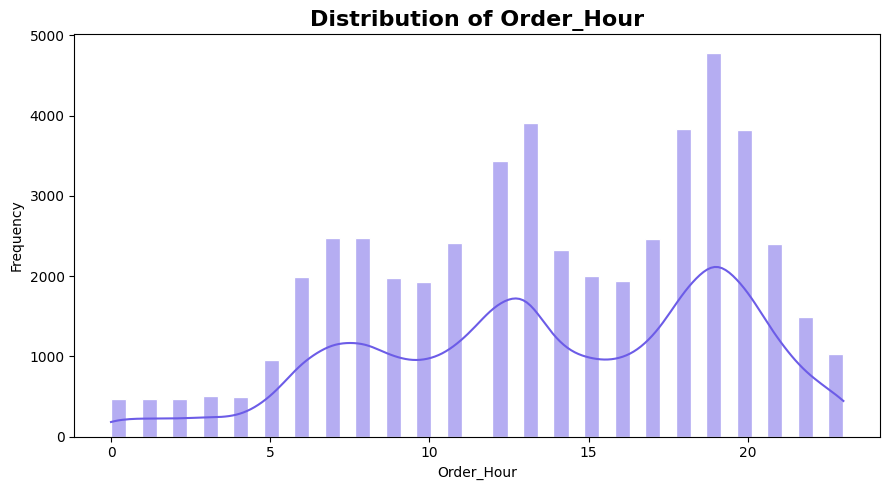

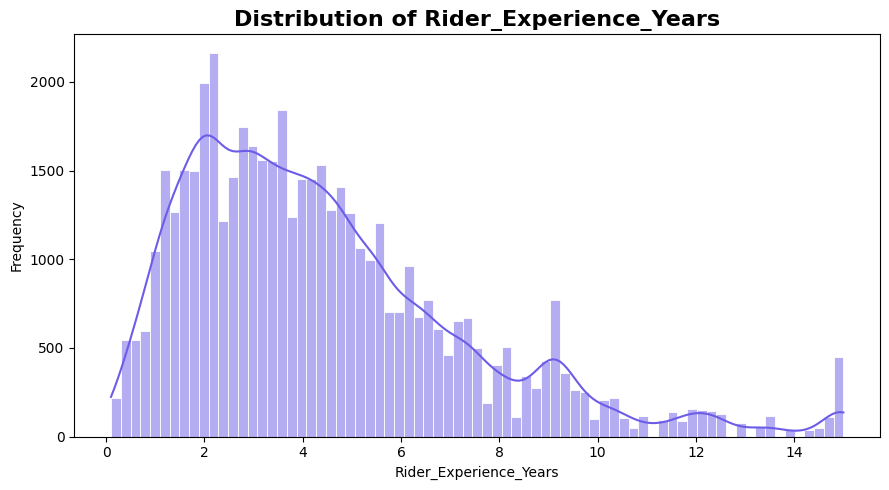

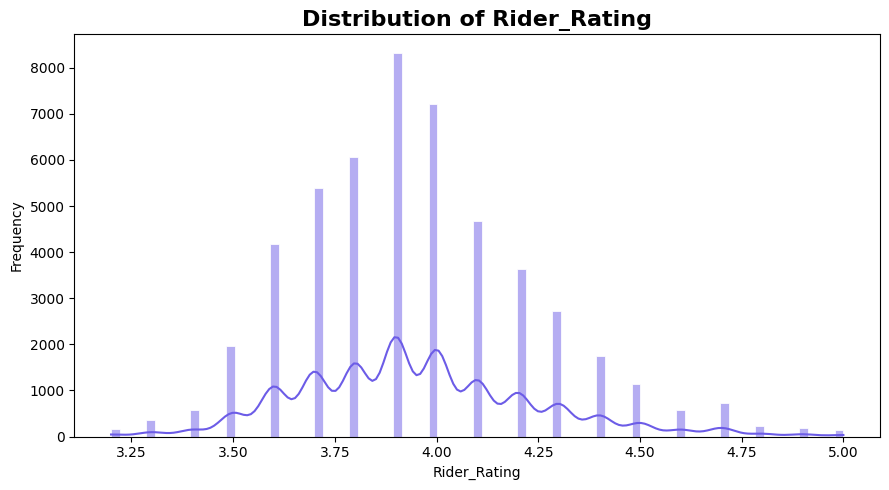

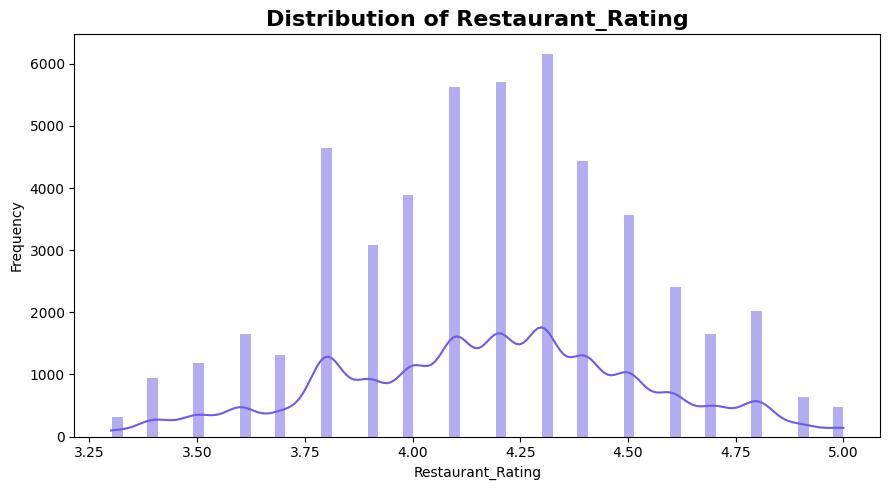

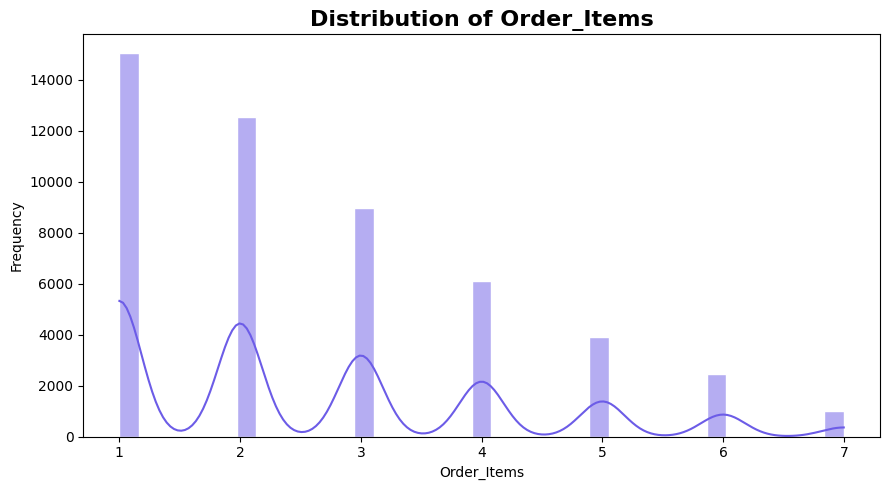

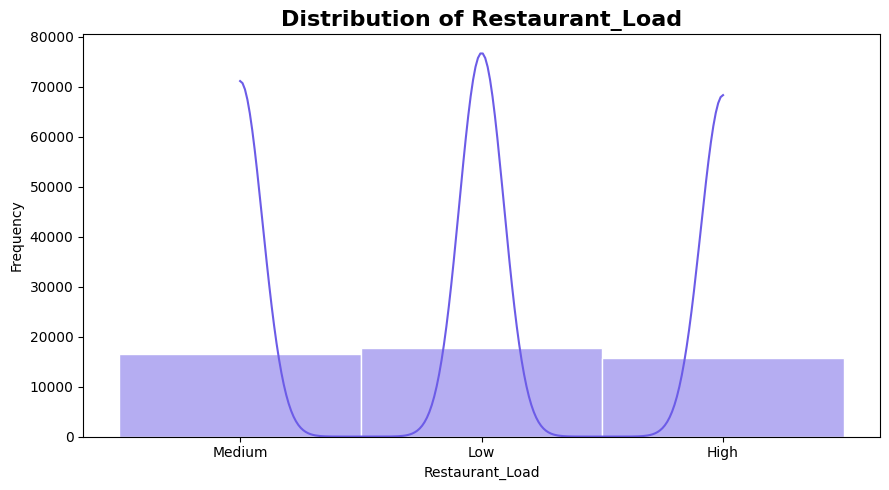

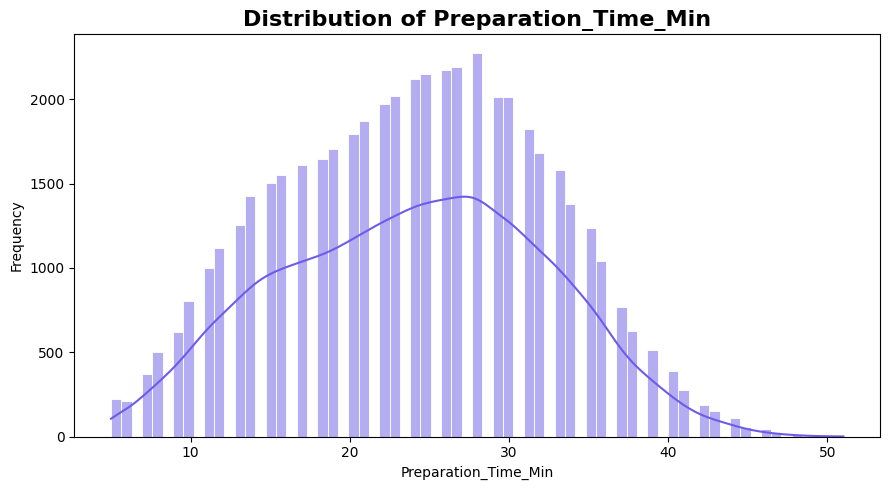

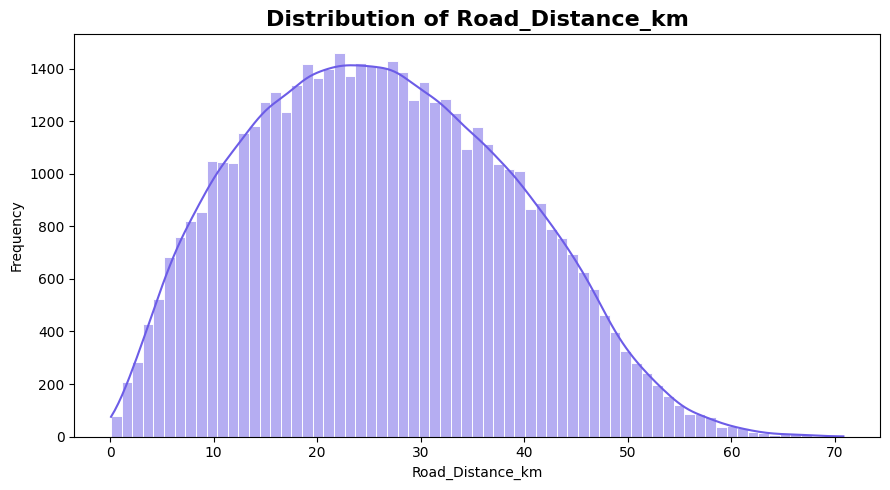

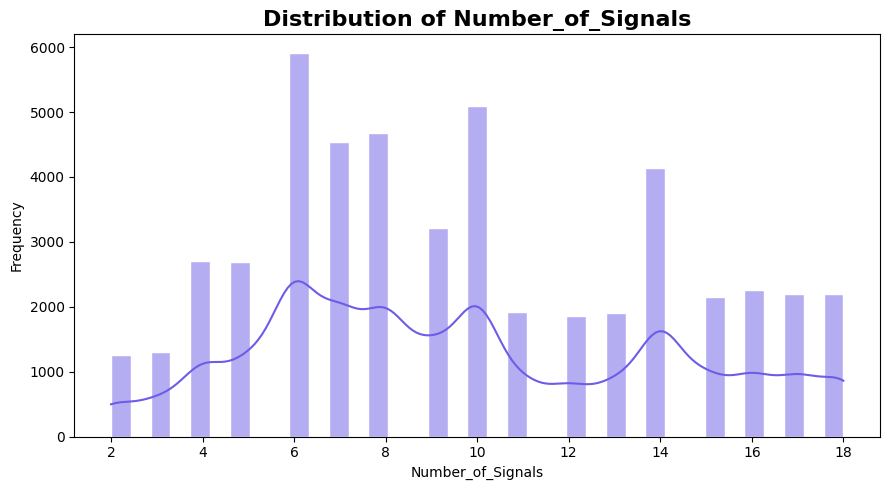

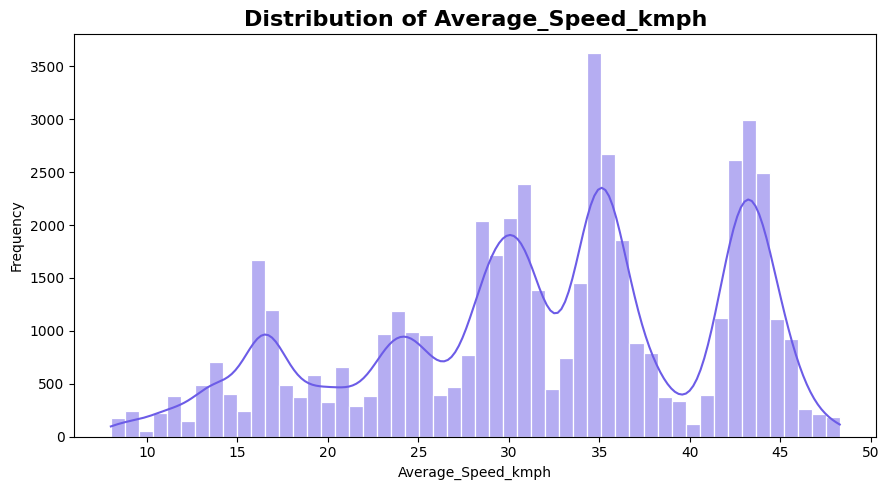

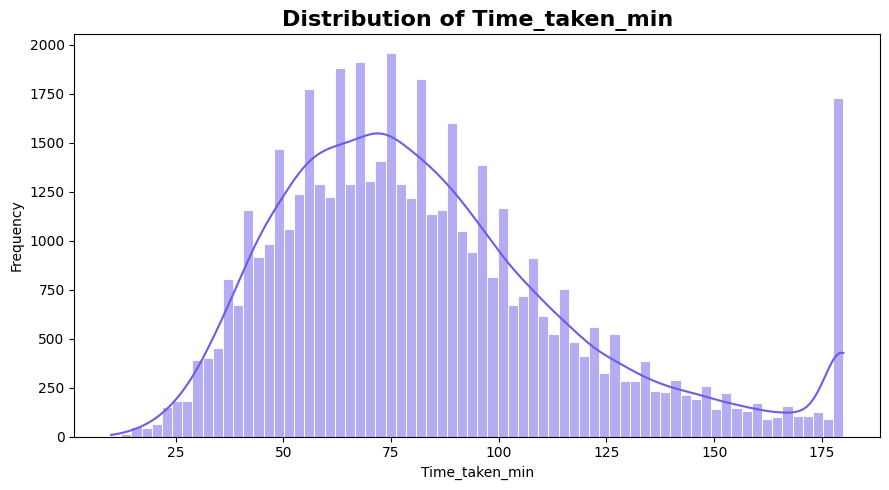

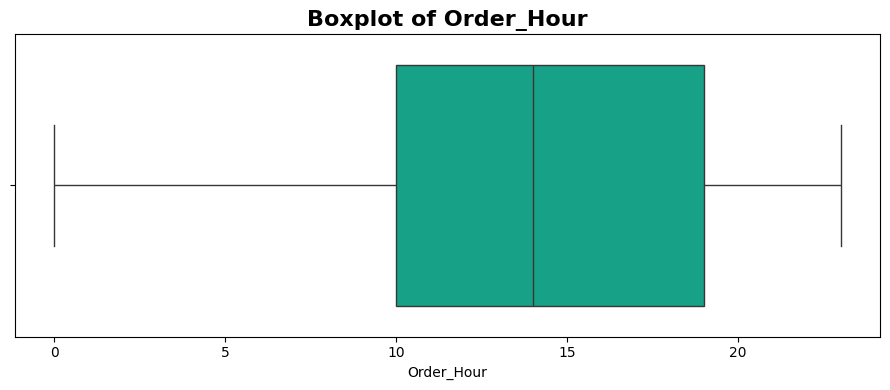

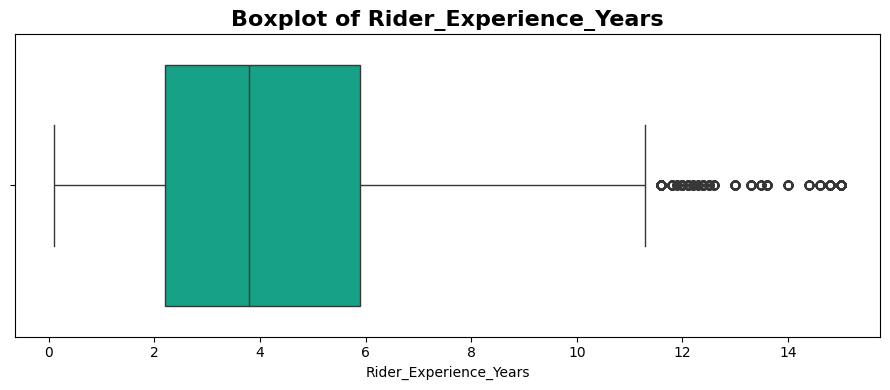

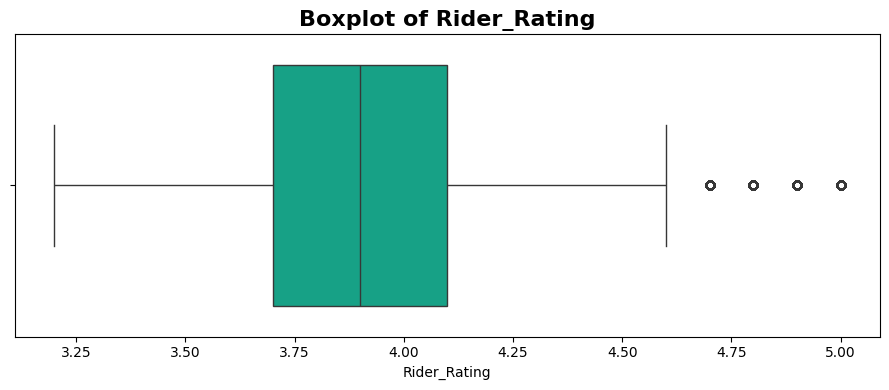

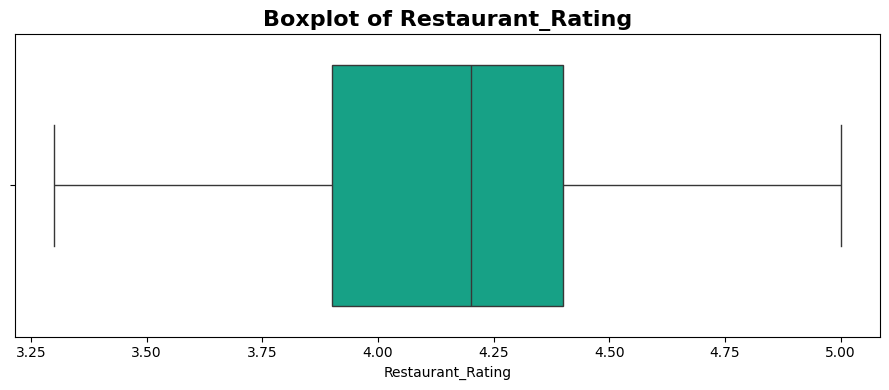

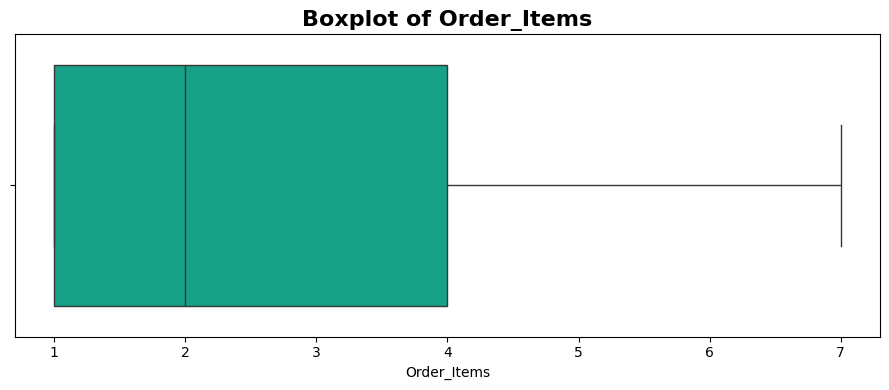

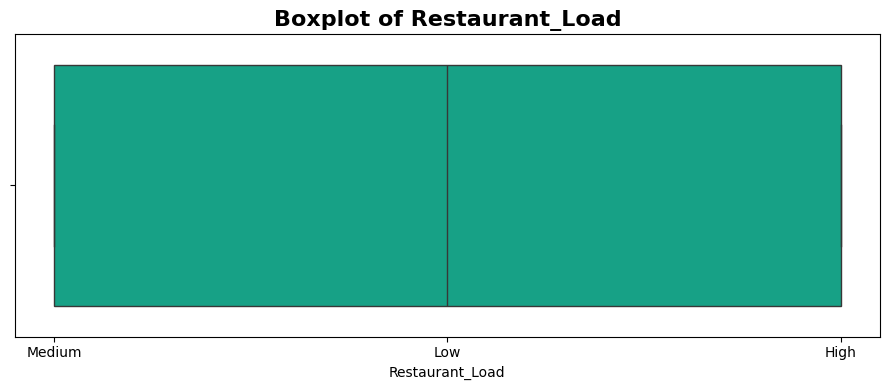

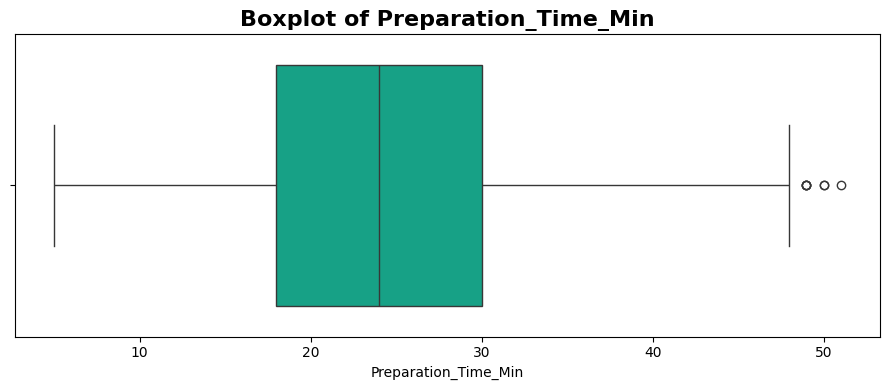

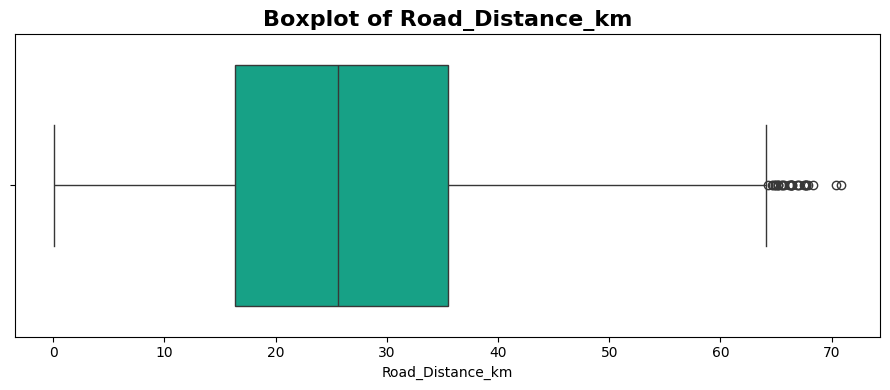

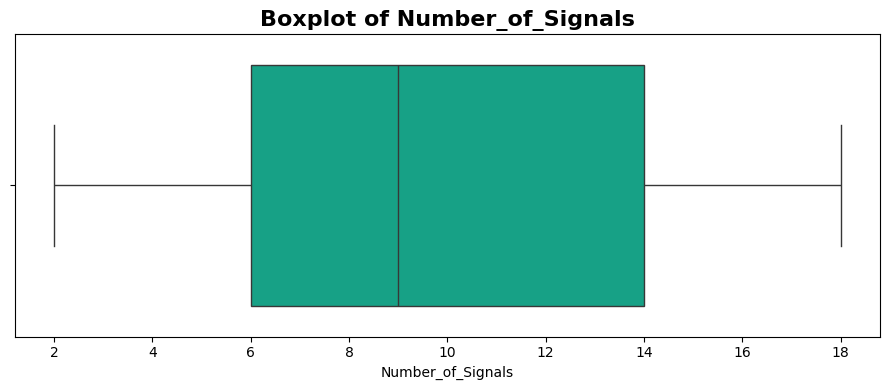

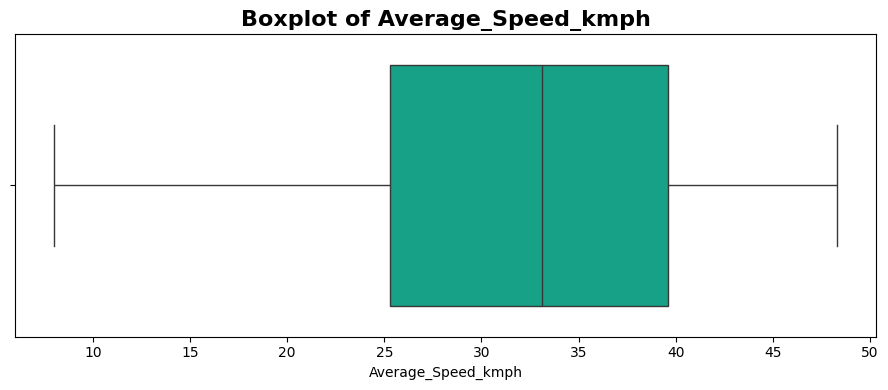

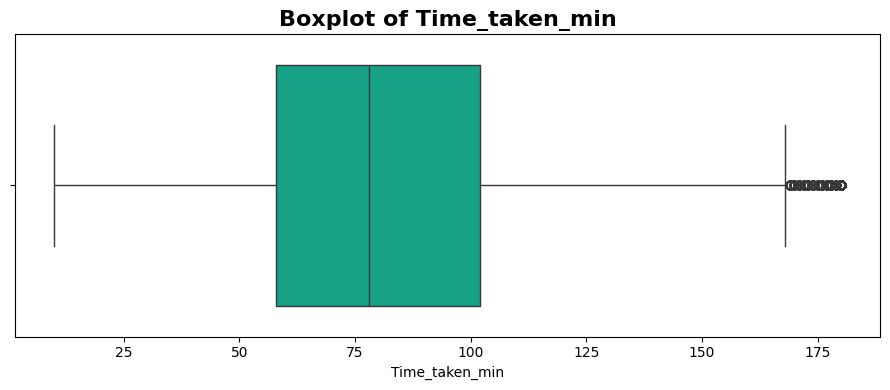

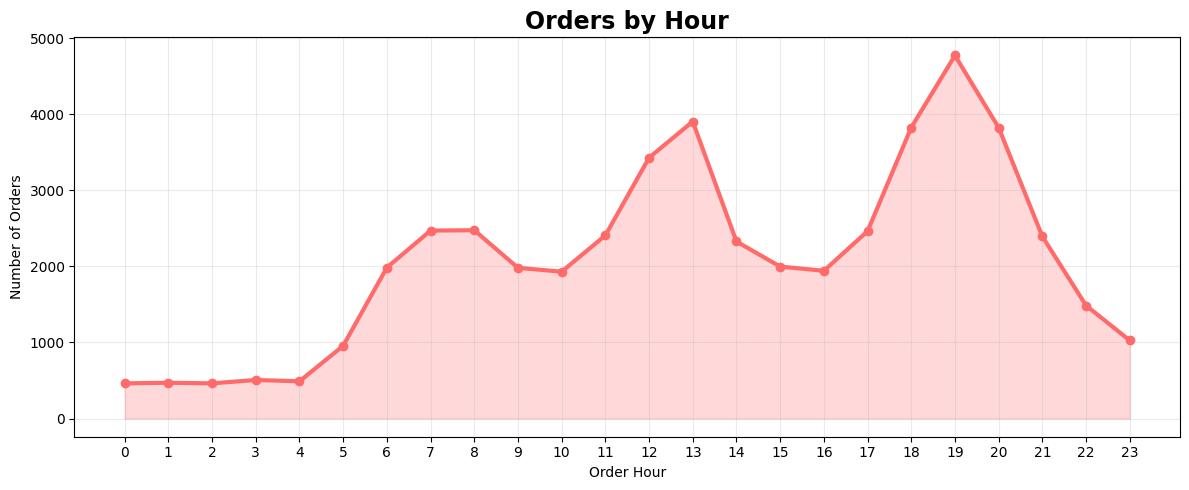

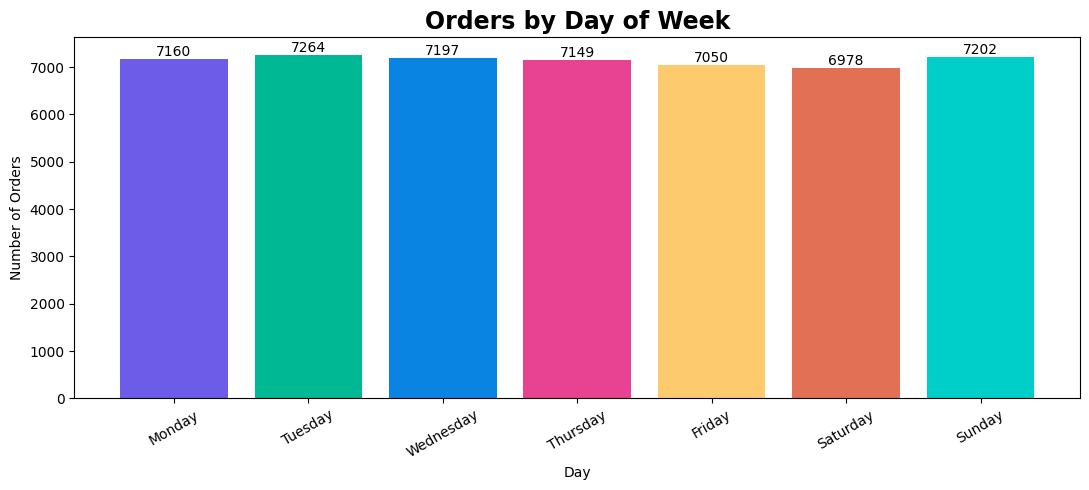

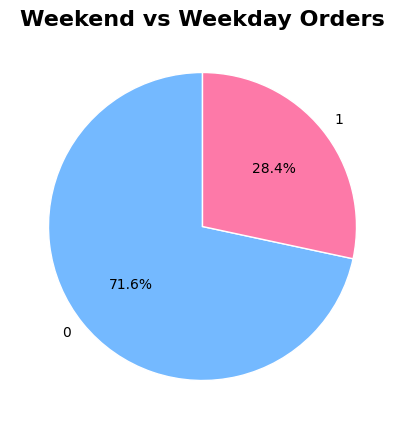

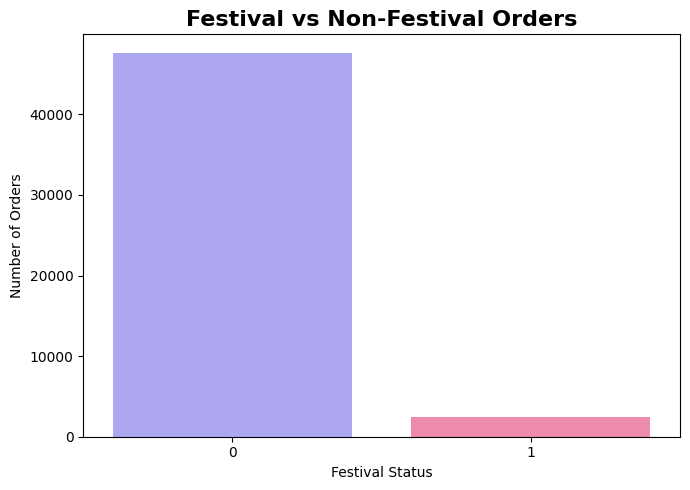

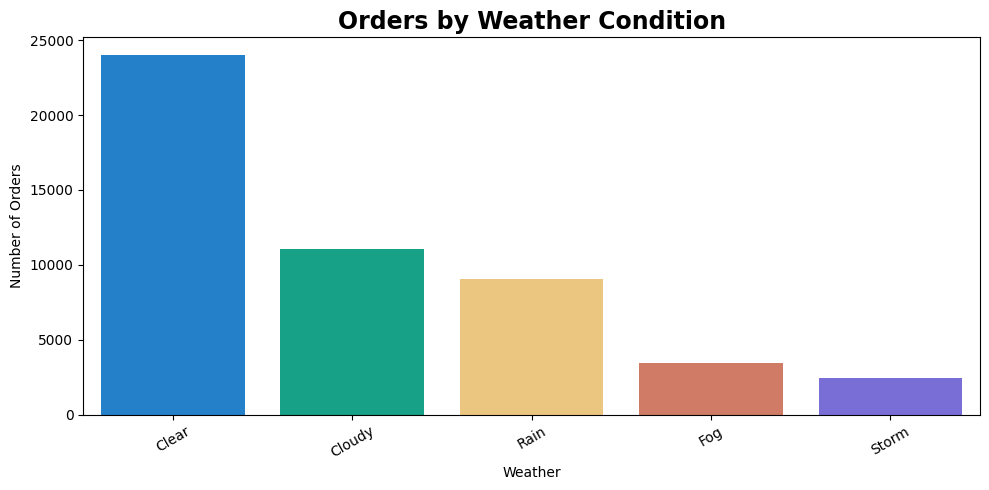

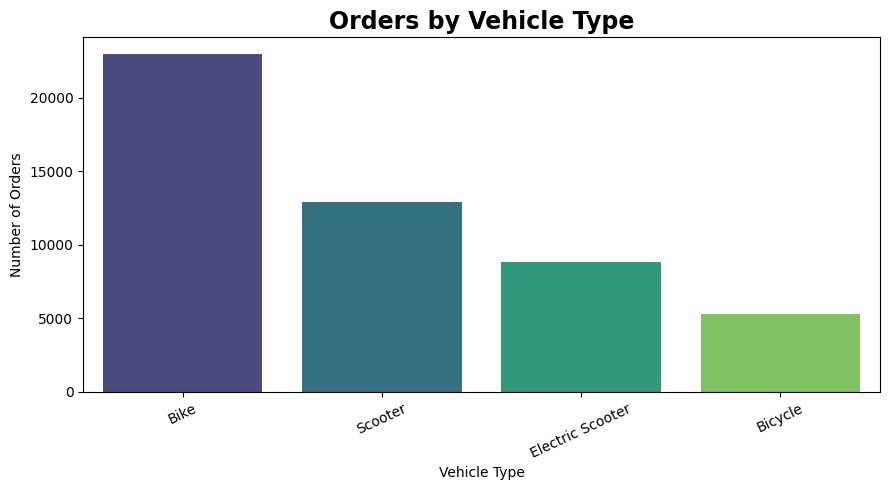

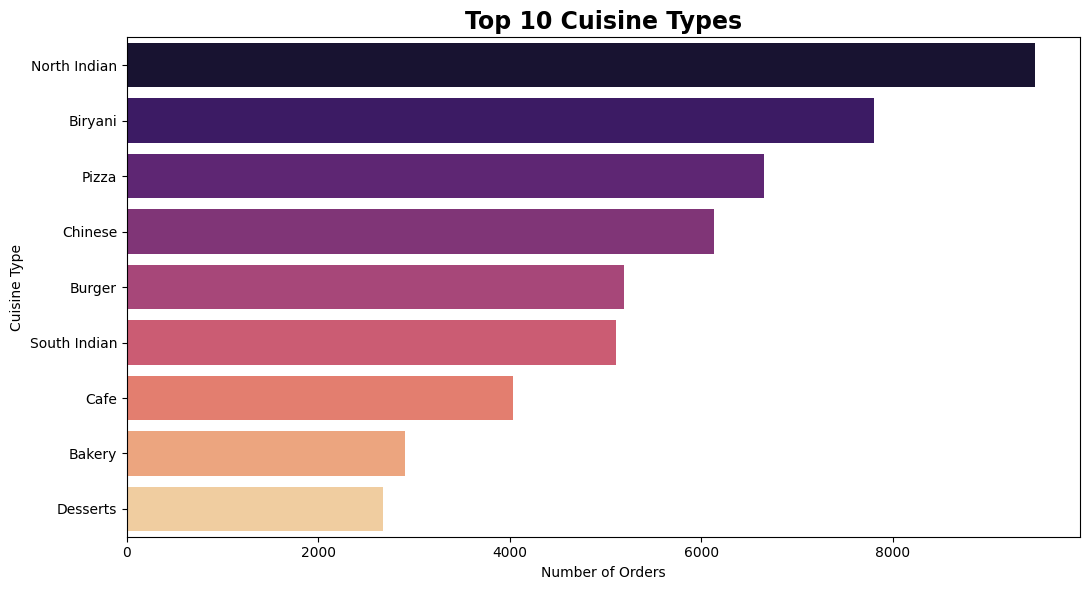

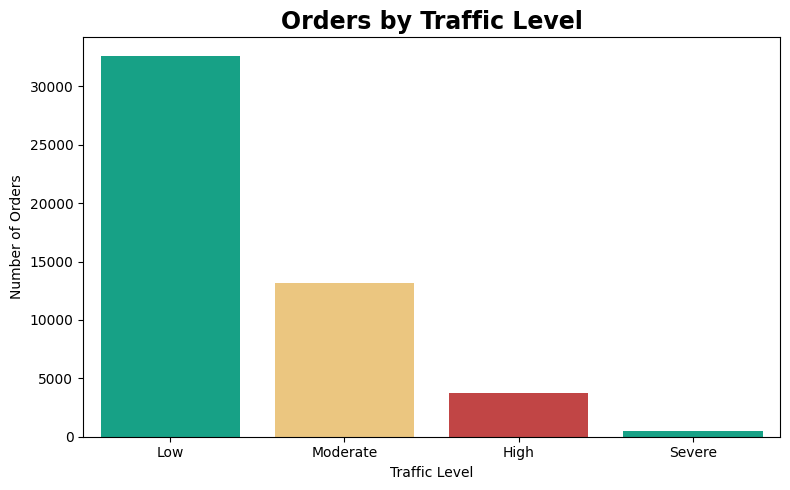

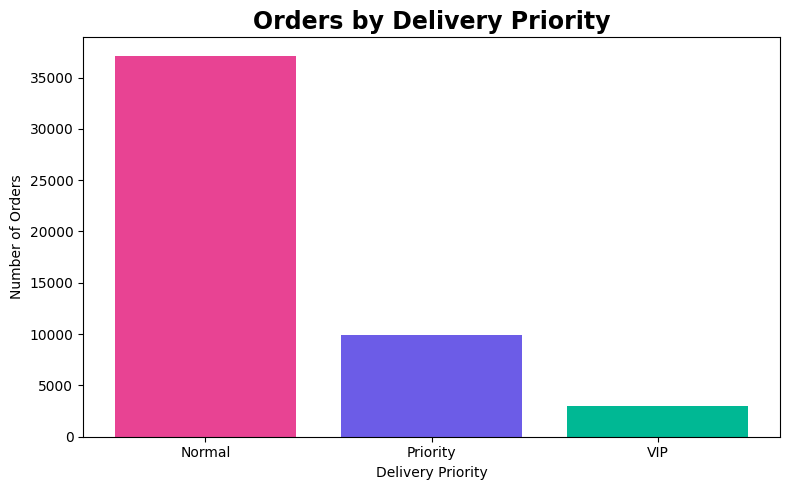

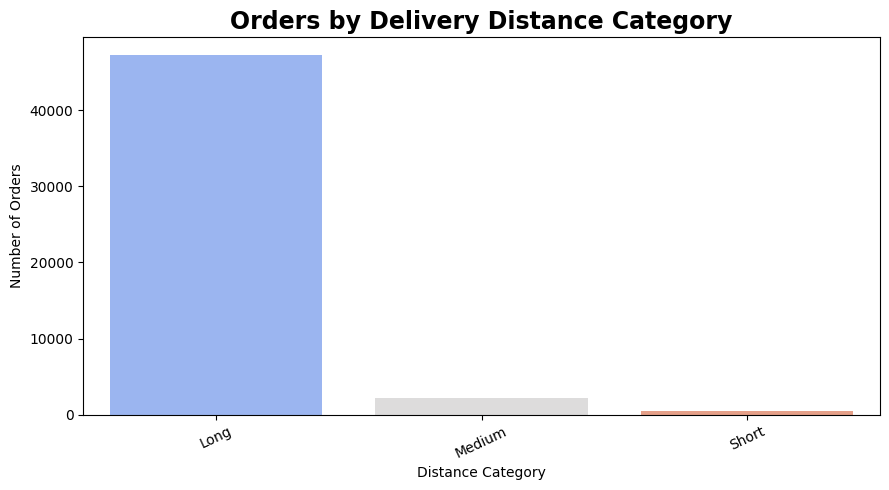

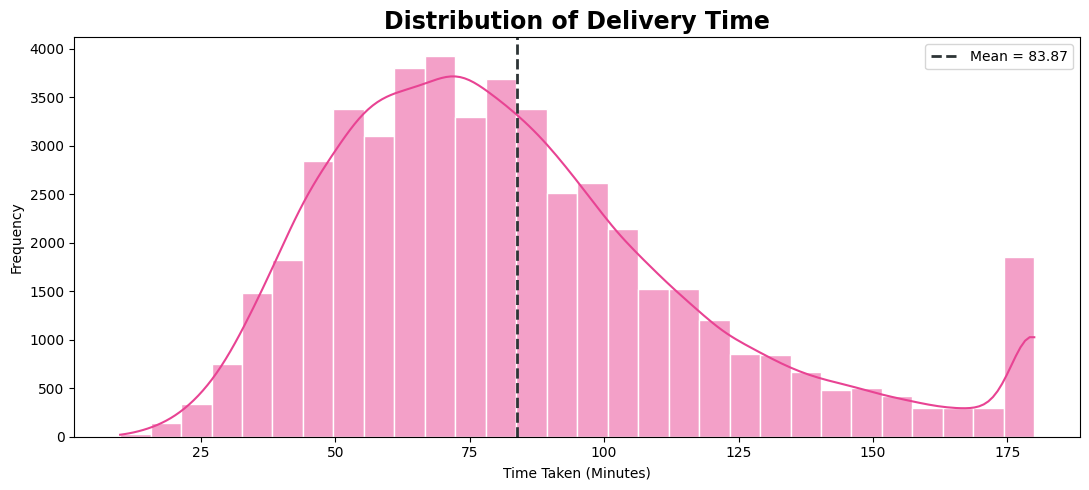

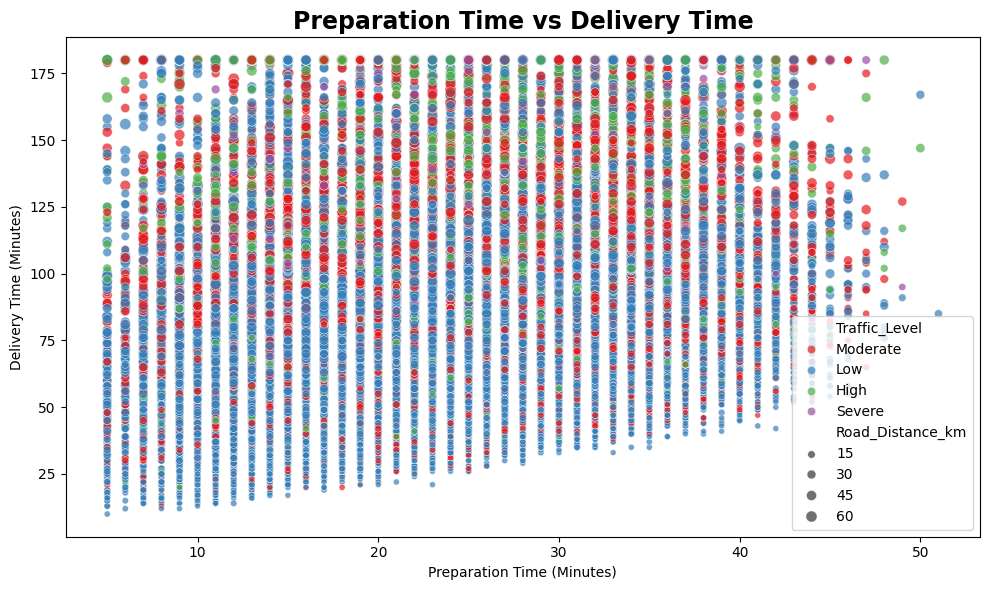

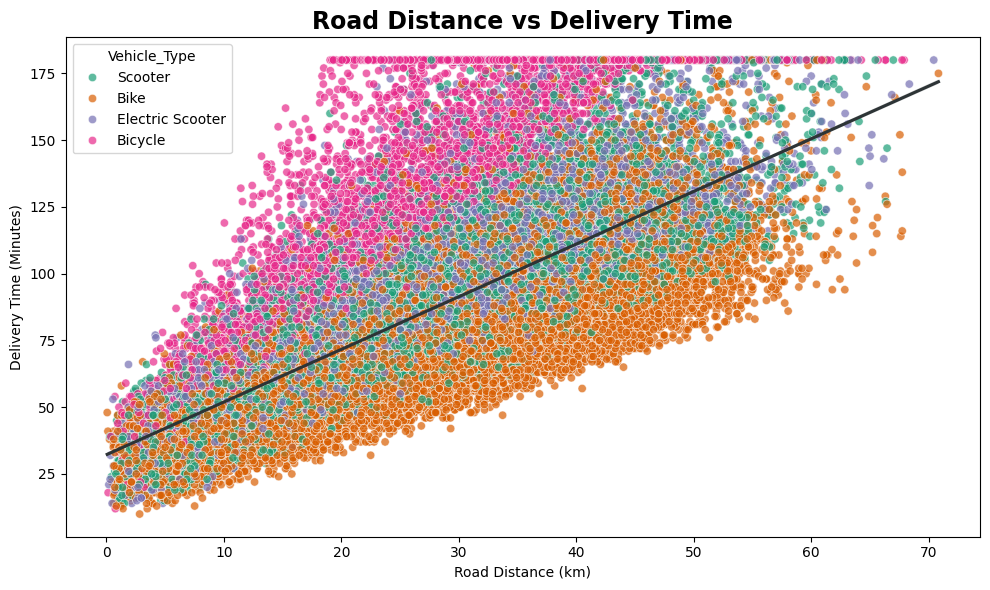

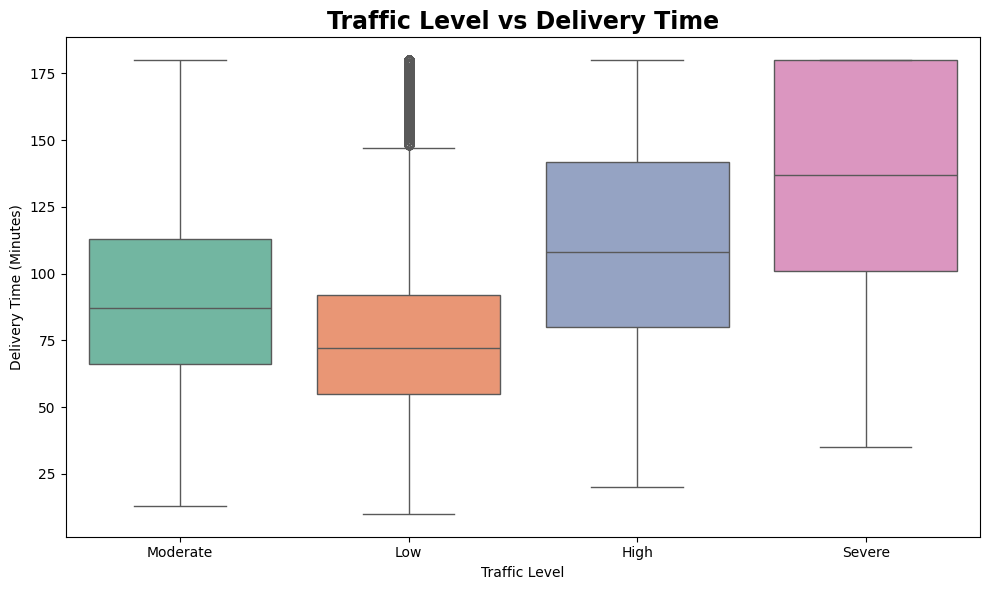

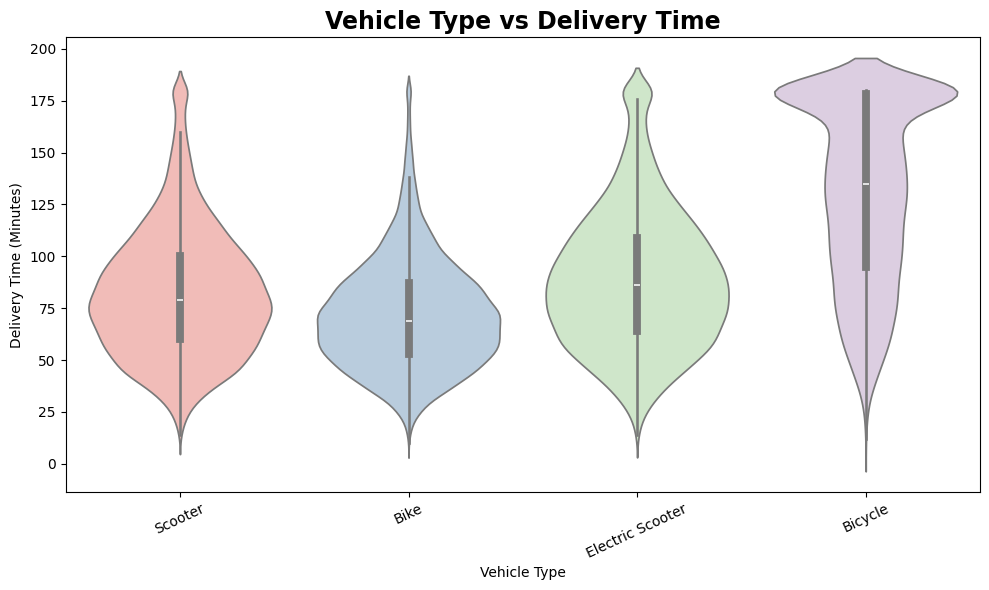

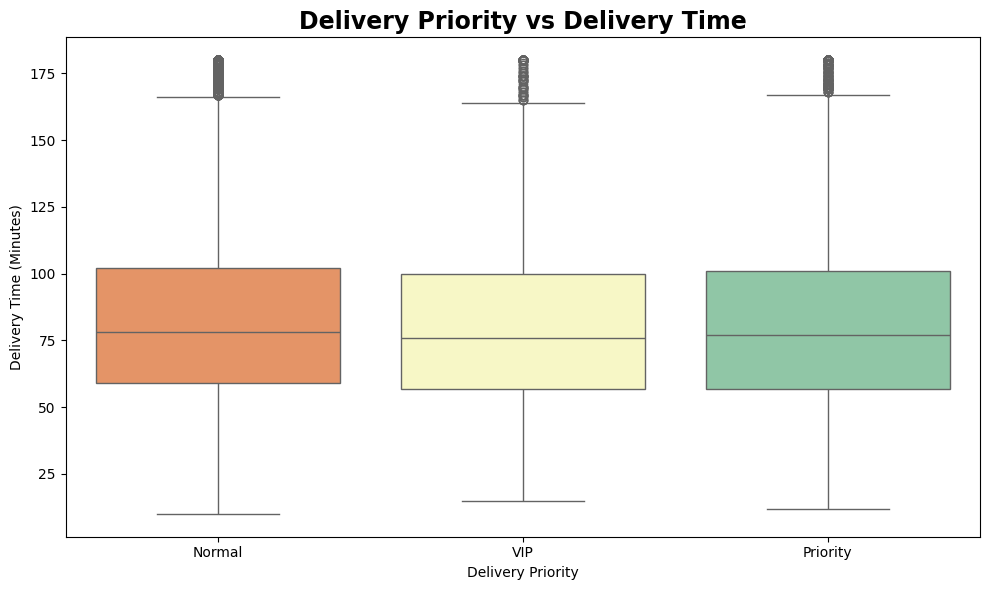

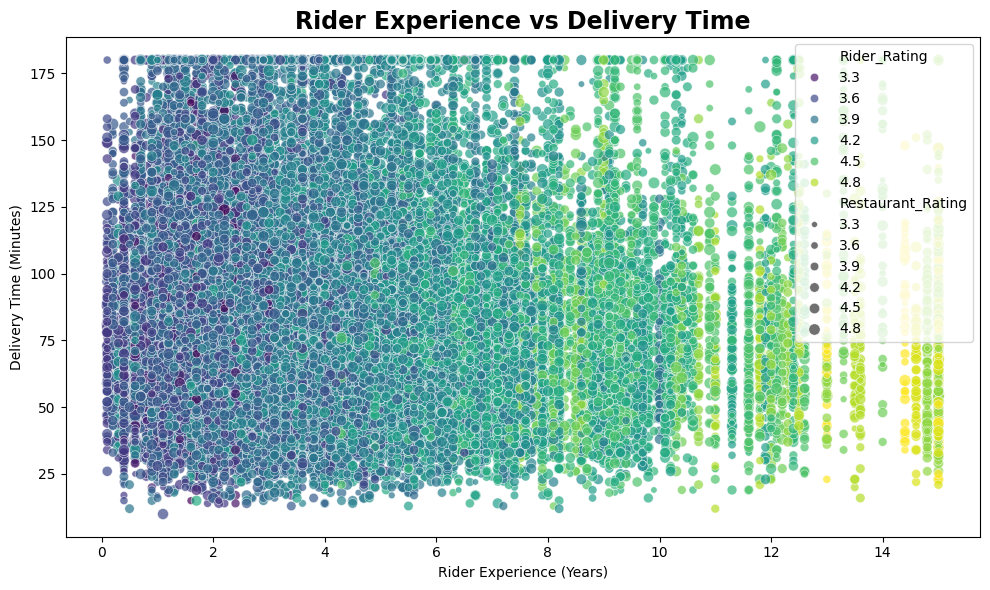

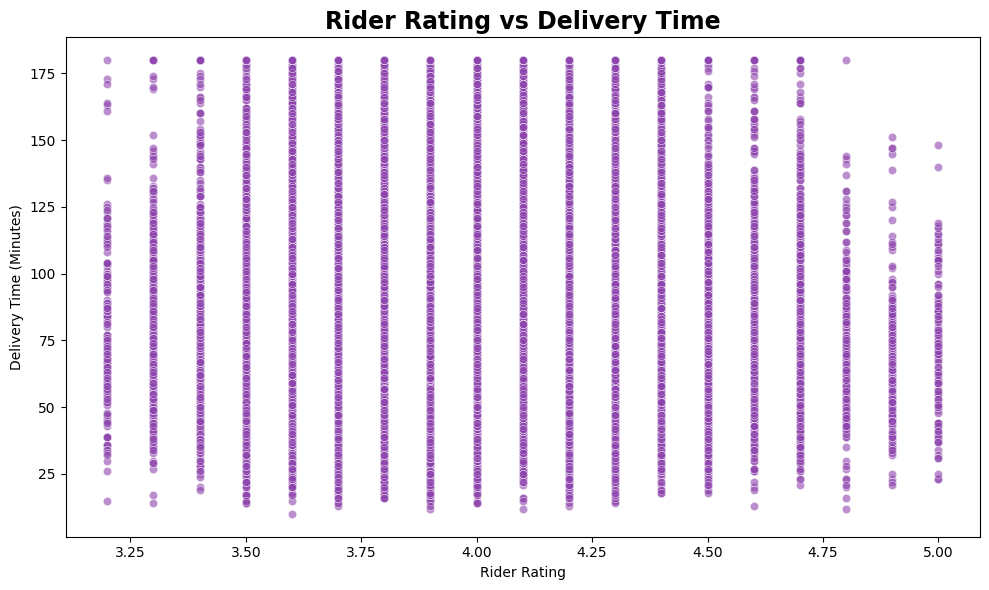

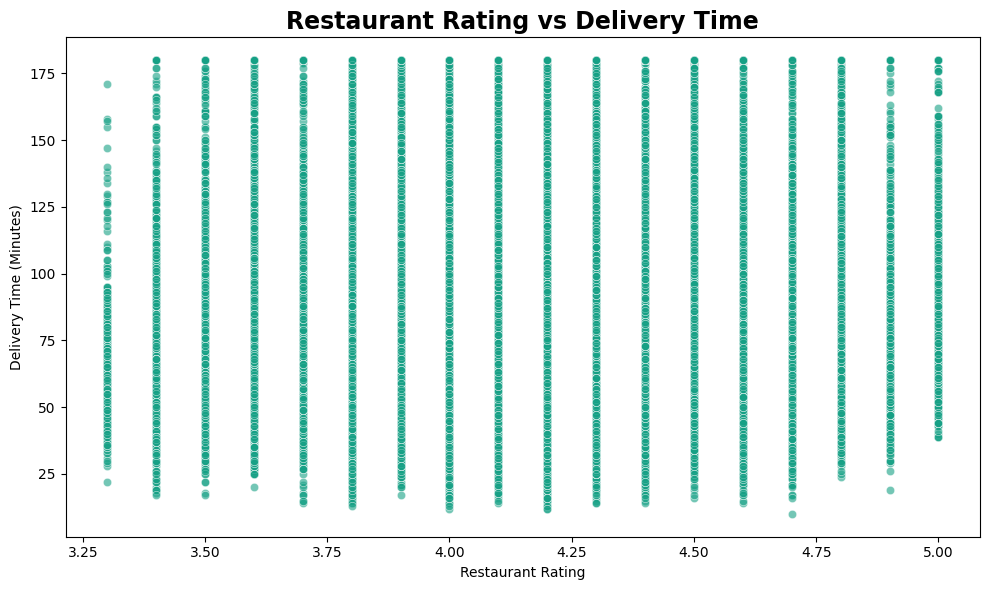

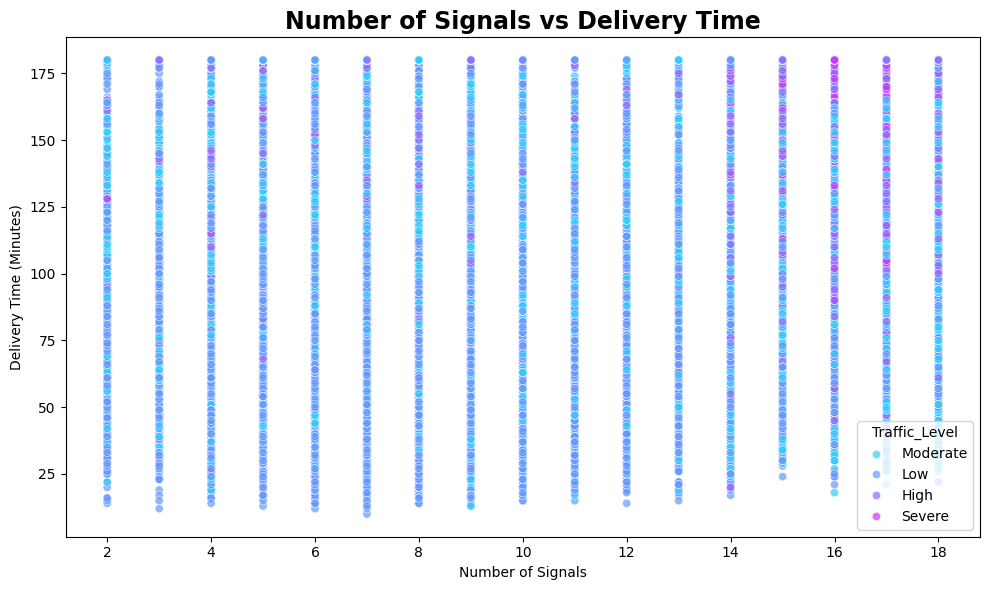

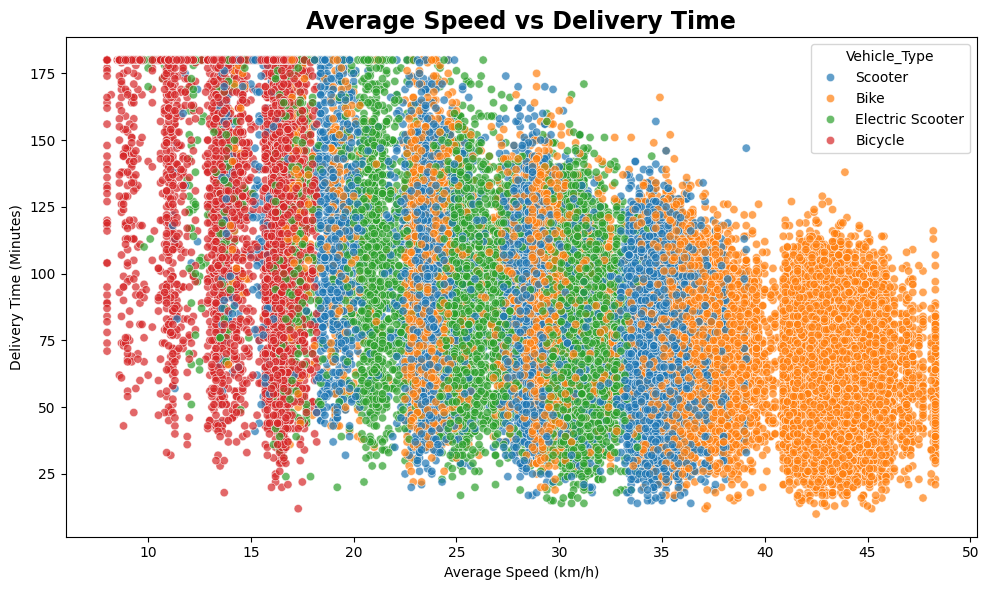

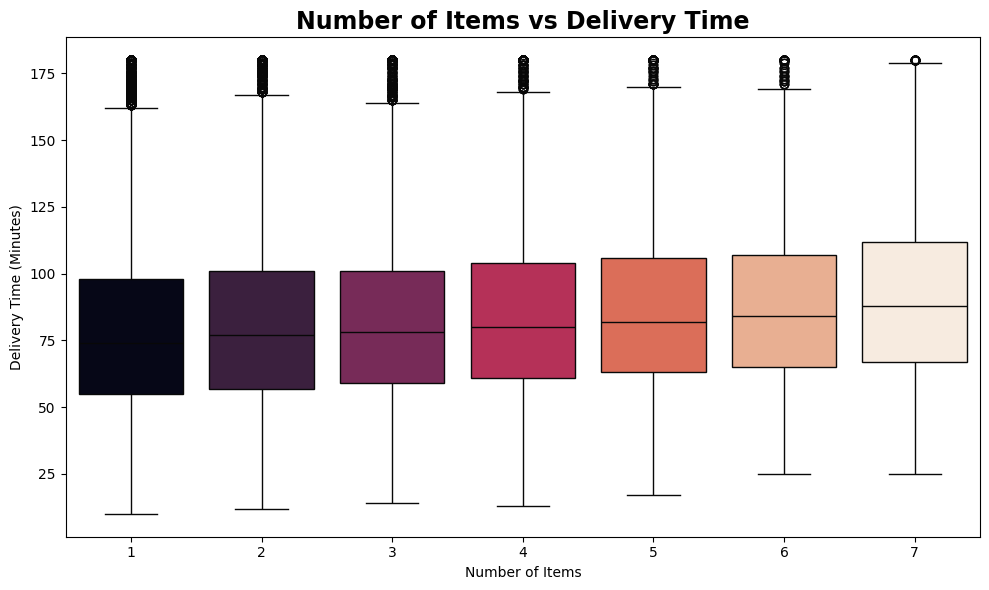

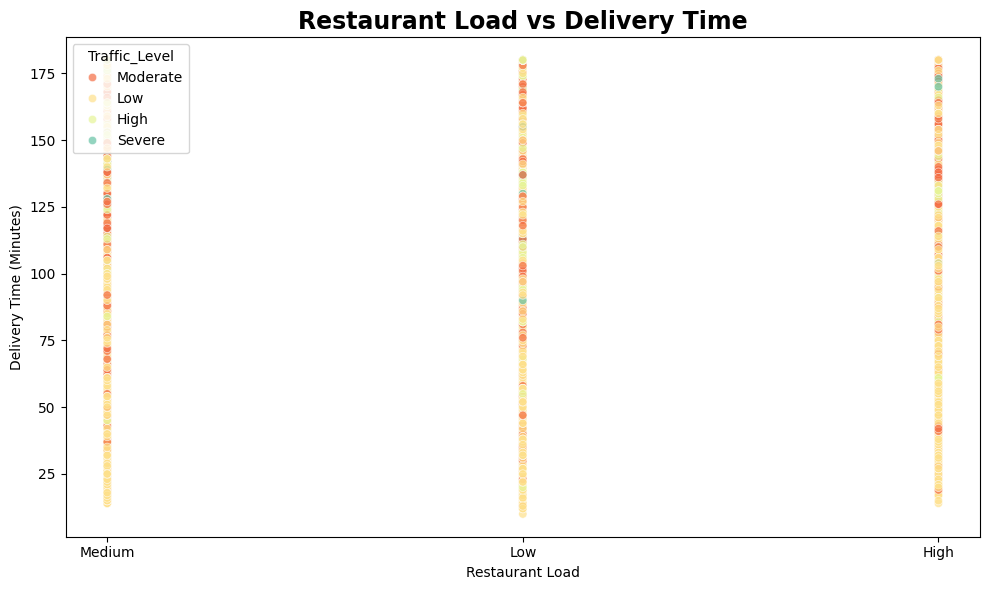

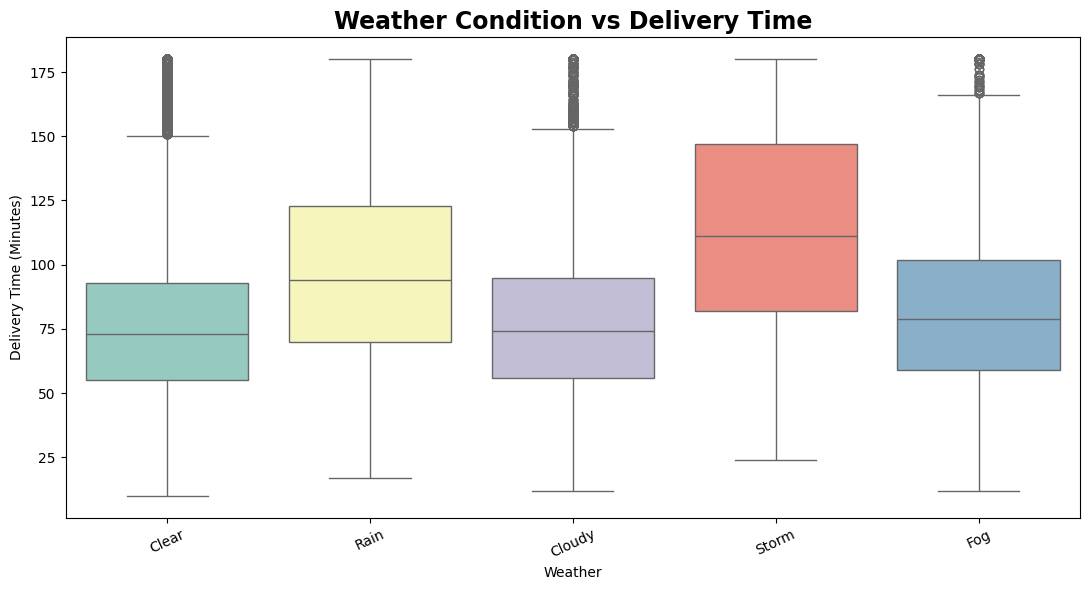

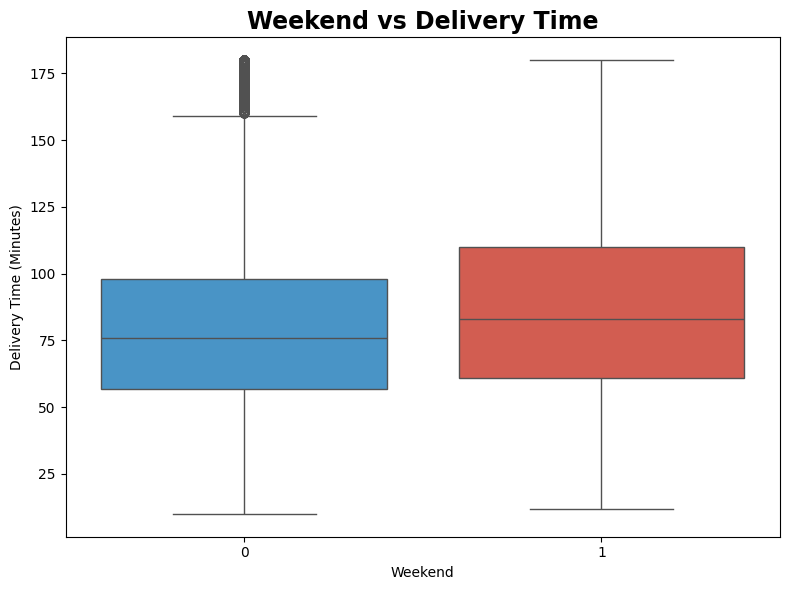

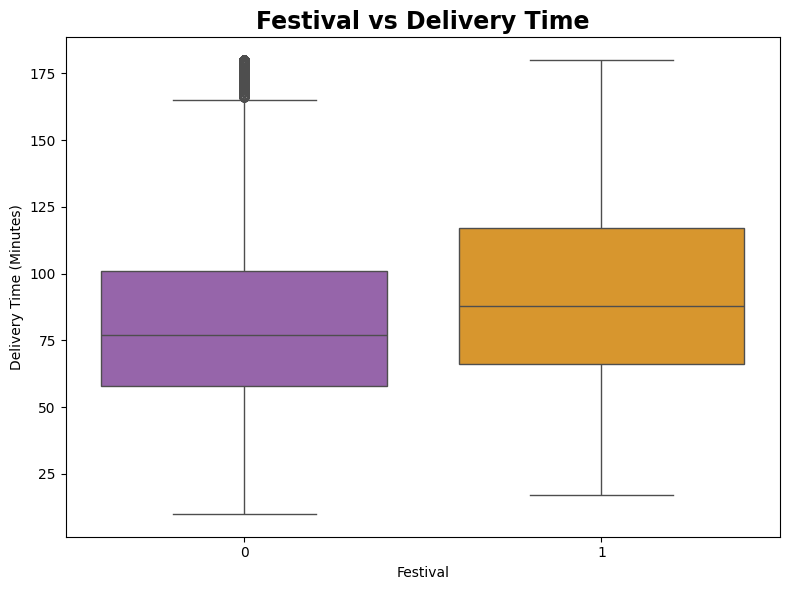

Numeric columns used for correlation:
['Order_Hour', 'Is_Weekend', 'Is_Festival', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Order_Items', 'Preparation_Time_Min', 'Road_Distance_km', 'Number_of_Signals', 'Average_Speed_kmph', 'Time_taken_min']


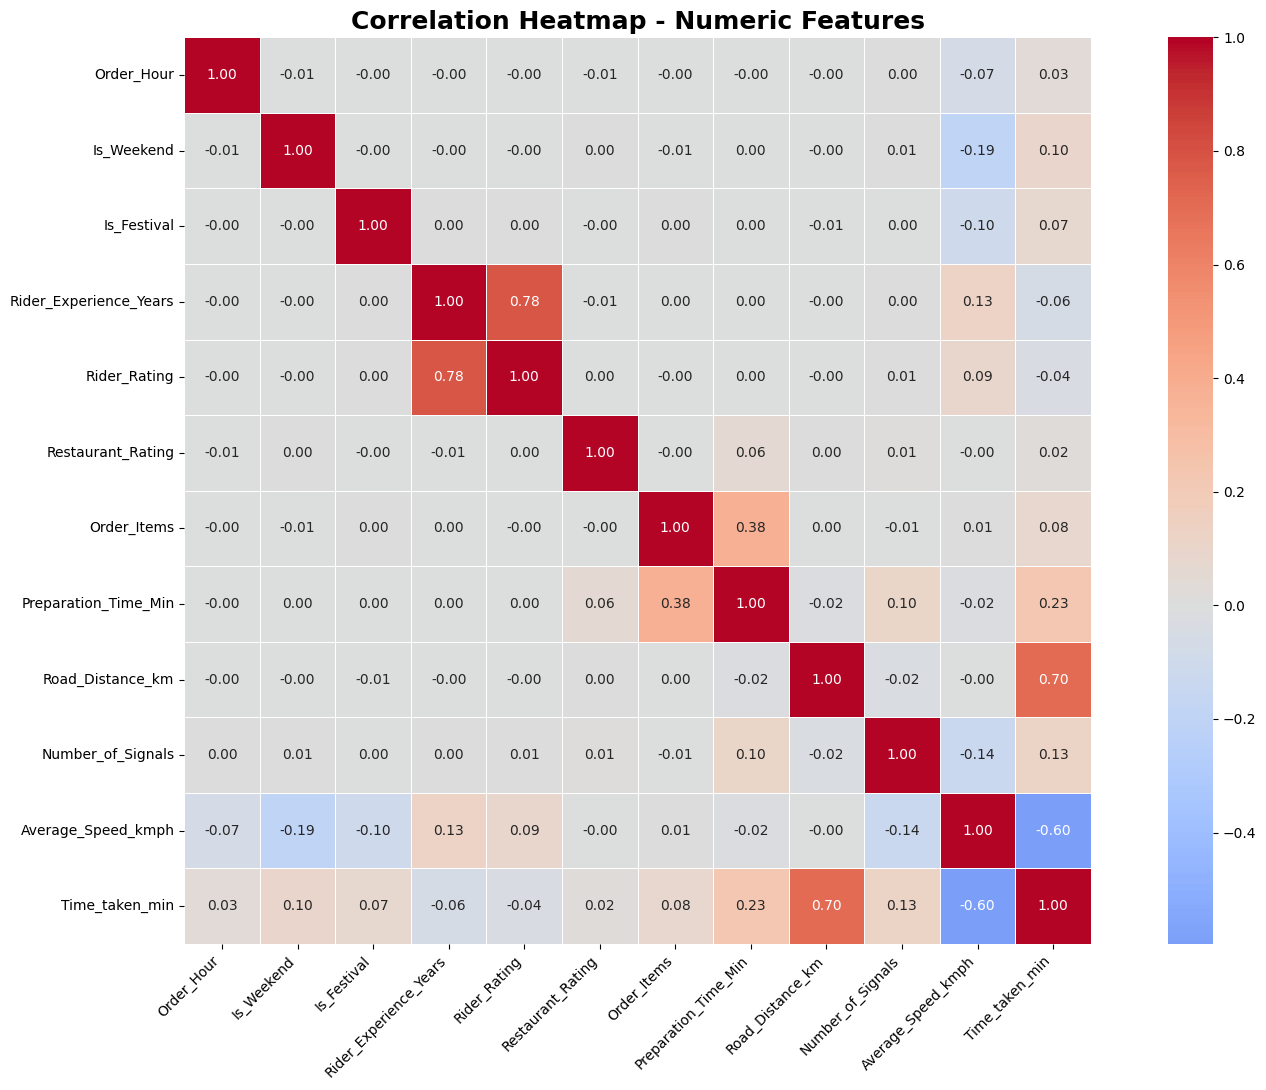

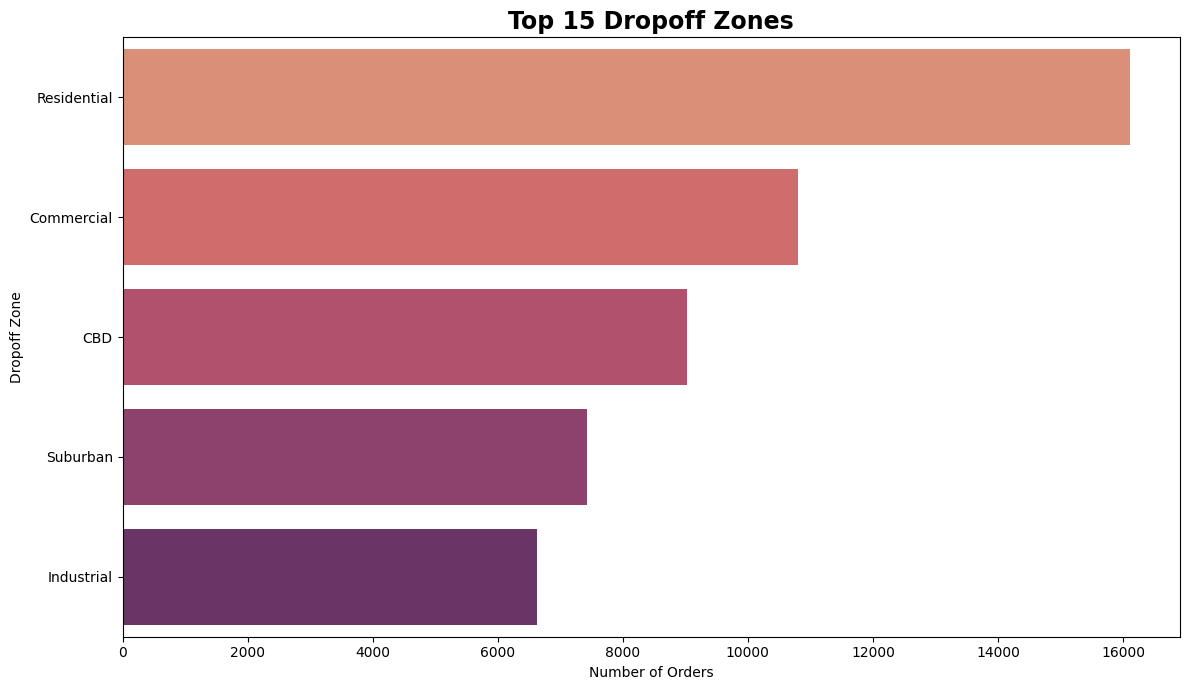

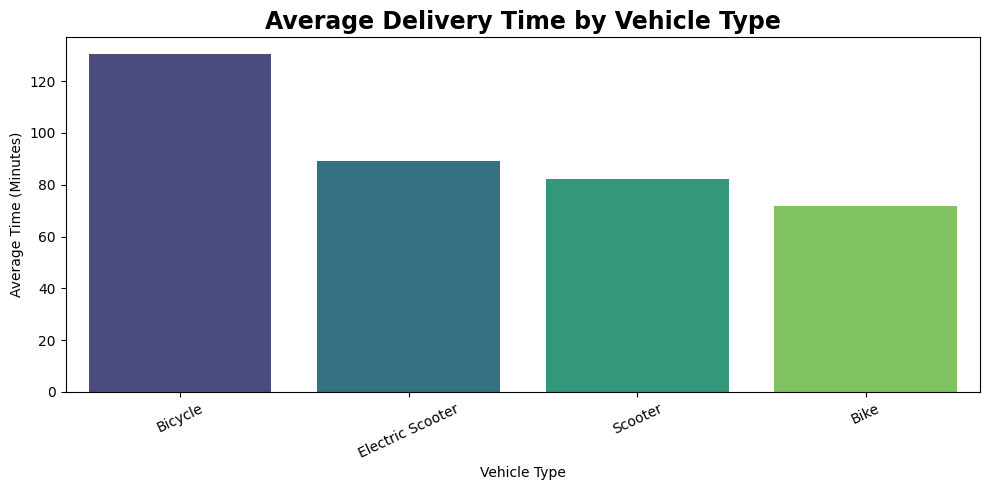

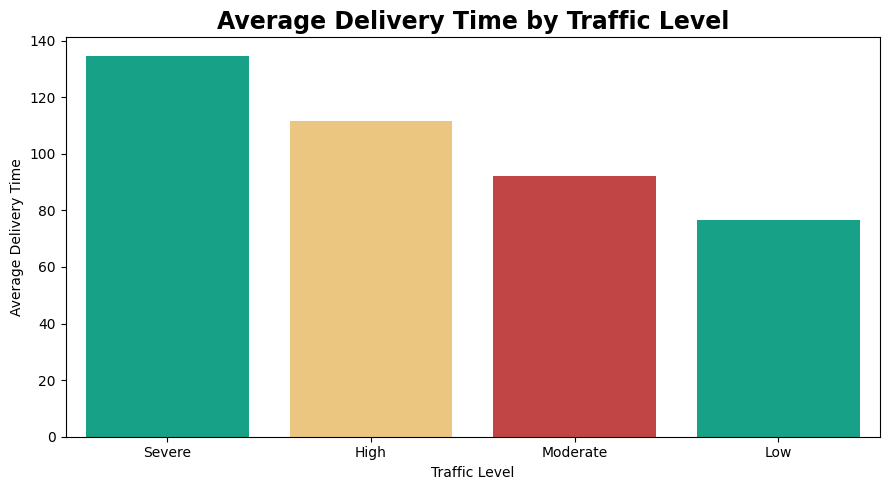

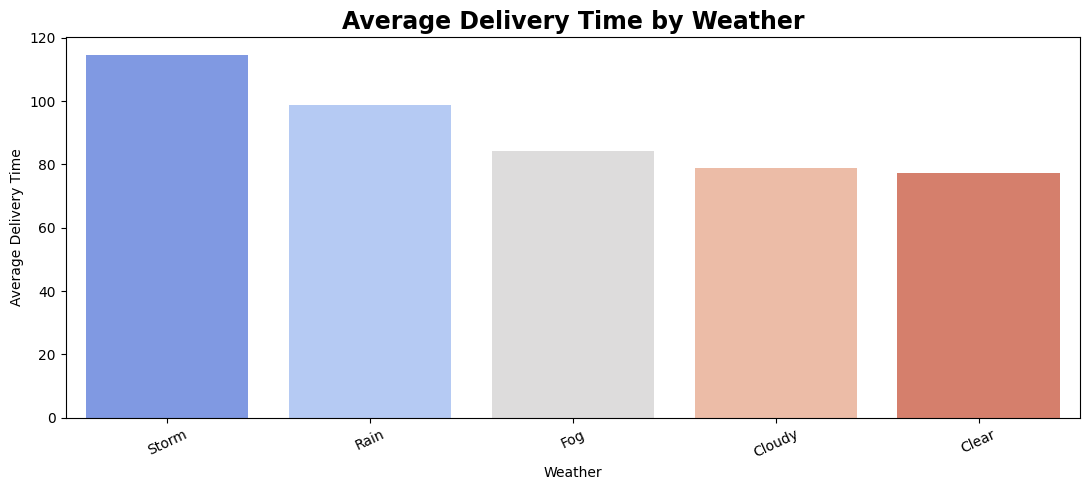

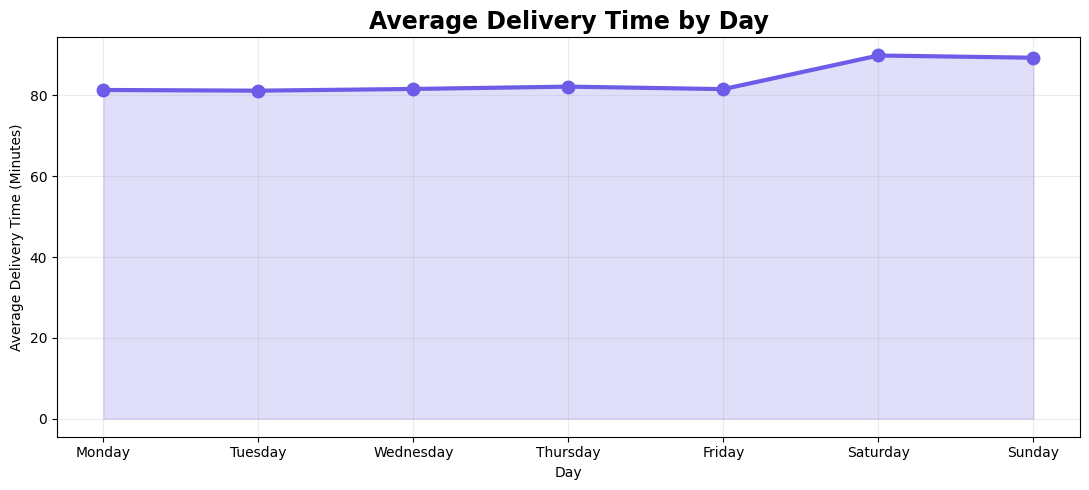

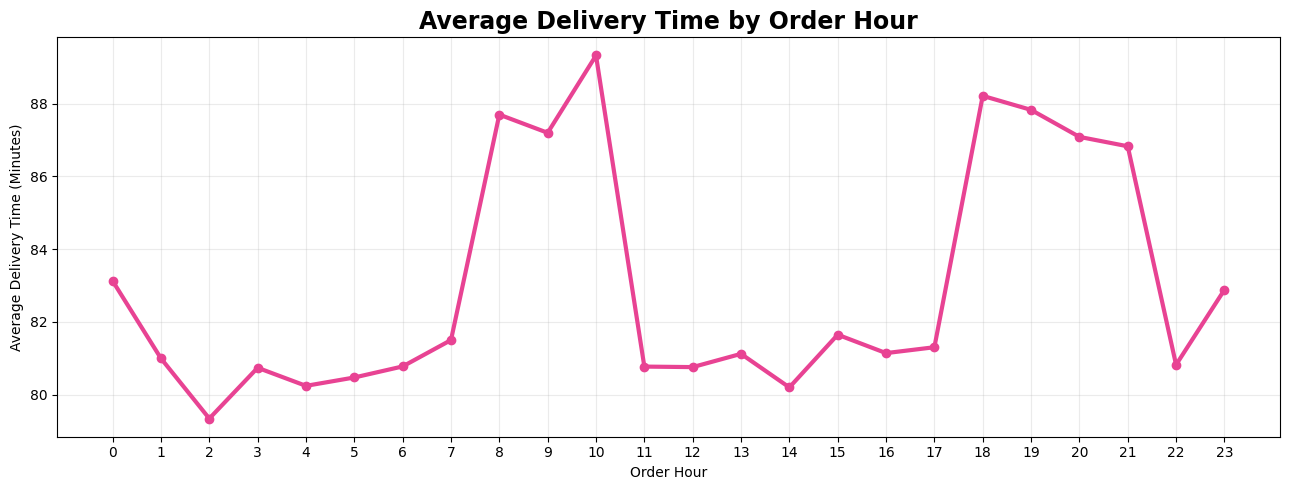

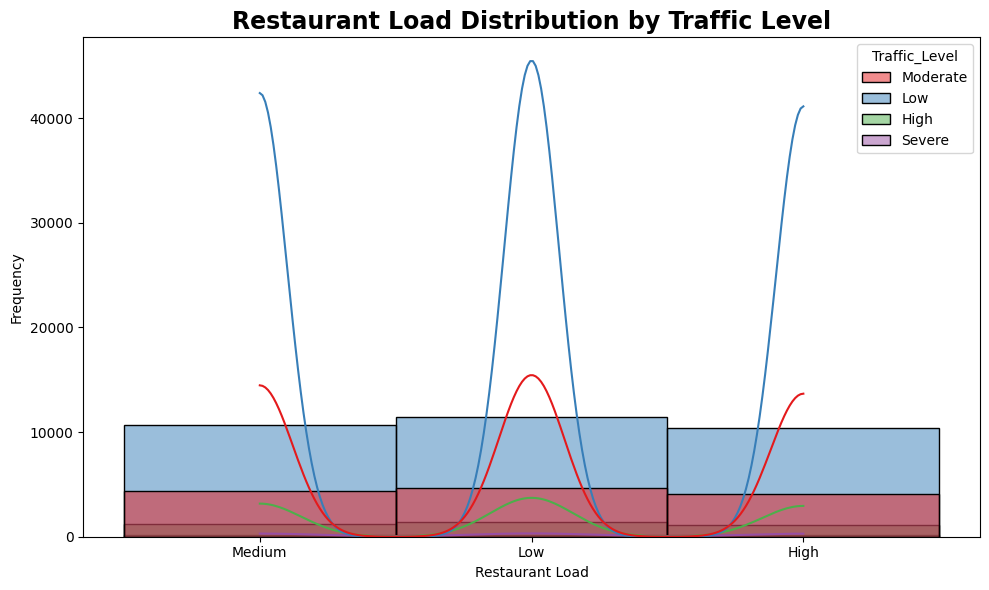

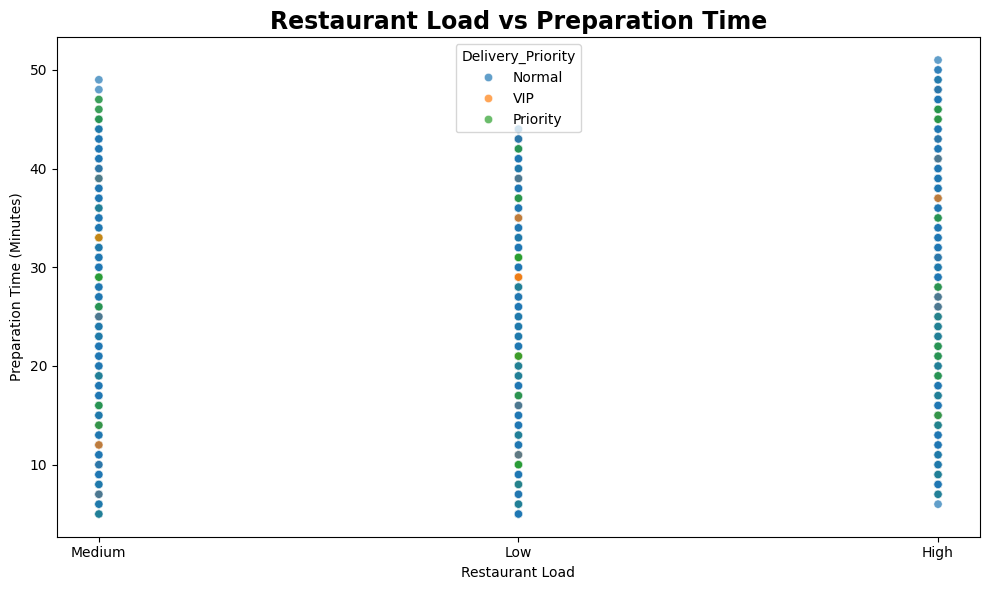


FOOD DELIVERY DATASET - KPI SUMMARY
Total Orders              : 50,000
Average Delivery Time     : 83.87 min
Median Delivery Time      : 78.00 min
Maximum Delivery Time     : 180.00 min
Minimum Delivery Time     : 10.00 min
Average Distance          : 26.20 km
Average Preparation Time  : 24.03 min
Average Rider Rating      : 3.95
Average Restaurant Rating : 4.18
Average Speed             : 31.76 km/h

Most Common Vehicle:
Bike

Most Common Weather:
Clear

Most Common Traffic Level:
Low

Most Common Cuisine:
North Indian

VISUALIZATION COMPLETED


In [14]:

import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option("display.max_columns", None)


print("=" * 70)
print("DATASET SHAPE")
print("=" * 70)
print(df.shape)

print("\n" + "=" * 70)
print("COLUMNS")
print("=" * 70)
print(df.columns)

print("\n" + "=" * 70)
print("FIRST 5 ROWS")
print("=" * 70)
display(df.head())


# ============================================================
# 3. BASIC DATA INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())

print("\n" + "=" * 70)
print("DUPLICATE ROWS")
print("=" * 70)

print("Duplicates:", df.duplicated().sum())

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

display(df.describe(include="all").T)


# ============================================================
# 4. DATE CONVERSION
# ============================================================

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

print("\nOrder Date Range:")
print(df["Order_Date"].min())
print(df["Order_Date"].max())


# ============================================================
# 5. MISSING VALUE VISUALIZATION
# ============================================================

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:

    plt.figure(figsize=(12, 5))

    bars = plt.bar(
        missing.index,
        missing.values,
        color=[
            "#FF6B6B",
            "#4ECDC4",
            "#FFD166",
            "#6C5CE7",
            "#00B894",
            "#E17055"
        ][:len(missing)]
    )

    plt.title(
        "Missing Values by Column",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")

    plt.xticks(rotation=45)

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            int(bar.get_height()),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. NUMERICAL COLUMNS
# ============================================================

numeric_cols = [
    "Order_Hour",
    "Rider_Experience_Years",
    "Rider_Rating",
    "Restaurant_Rating",
    "Order_Items",
    "Restaurant_Load",
    "Preparation_Time_Min",
    "Road_Distance_km",
    "Number_of_Signals",
    "Average_Speed_kmph",
    "Time_taken_min"
]

numeric_cols = [
    col for col in numeric_cols
    if col in df.columns
]


# ============================================================
# 7. NUMERICAL DISTRIBUTIONS
# ============================================================

for col in numeric_cols:

    plt.figure(figsize=(9, 5))

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color="#6C5CE7",
        edgecolor="white"
    )

    plt.title(
        f"Distribution of {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 8. BOXPLOTS FOR NUMERICAL FEATURES
# ============================================================

for col in numeric_cols:

    plt.figure(figsize=(9, 4))

    sns.boxplot(
        x=df[col],
        color="#00B894"
    )

    plt.title(
        f"Boxplot of {col}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


# ============================================================
# 9. ORDER HOUR ANALYSIS
# ============================================================

hour_count = (
    df["Order_Hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 5))

plt.plot(
    hour_count.index,
    hour_count.values,
    marker="o",
    linewidth=3,
    color="#FF6B6B"
)

plt.fill_between(
    hour_count.index,
    hour_count.values,
    alpha=0.25,
    color="#FF6B6B"
)

plt.title(
    "Orders by Hour",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Order Hour")
plt.ylabel("Number of Orders")

plt.xticks(range(0, 24))

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 10. DAY OF WEEK ANALYSIS
# ============================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_count = (
    df["Day_of_Week"]
    .value_counts()
    .reindex(day_order)
)

plt.figure(figsize=(11, 5))

bars = plt.bar(
    day_count.index,
    day_count.values,
    color=[
        "#6C5CE7",
        "#00B894",
        "#0984E3",
        "#E84393",
        "#FDCB6E",
        "#E17055",
        "#00CEC9"
    ]
)

plt.title(
    "Orders by Day of Week",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Day")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)

for bar in bars:

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 11. WEEKEND VS WEEKDAY
# ============================================================

weekend_count = df["Is_Weekend"].value_counts()

plt.figure(figsize=(7, 5))

plt.pie(
    weekend_count.values,
    labels=weekend_count.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#74B9FF", "#FD79A8"],
    wedgeprops={"edgecolor": "white"}
)

plt.title(
    "Weekend vs Weekday Orders",
    fontsize=16,
    fontweight="bold"
)

plt.show()


# ============================================================
# 12. FESTIVAL ANALYSIS
# ============================================================

festival_count = df["Is_Festival"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=festival_count.index,
    y=festival_count.values,
    hue=festival_count.index,
    palette=["#A29BFE", "#FD79A8"],
    legend=False
)

plt.title(
    "Festival vs Non-Festival Orders",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Festival Status")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


# ============================================================
# 13. WEATHER ANALYSIS
# ============================================================

weather_count = df["Weather"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=weather_count.index,
    y=weather_count.values,
    hue=weather_count.index,
    palette=[
        "#0984E3",
        "#00B894",
        "#FDCB6E",
        "#E17055",
        "#6C5CE7"
    ][:len(weather_count)],
    legend=False
)

plt.title(
    "Orders by Weather Condition",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Weather")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 14. VEHICLE TYPE ANALYSIS
# ============================================================

vehicle_count = df["Vehicle_Type"].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=vehicle_count.index,
    y=vehicle_count.values,
    hue=vehicle_count.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Orders by Vehicle Type",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Vehicle Type")
plt.ylabel("Number of Orders")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


# ============================================================
# 15. CUISINE TYPE
# ============================================================

cuisine_count = (
    df["Cuisine_Type"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(11, 6))

sns.barplot(
    y=cuisine_count.index,
    x=cuisine_count.values,
    hue=cuisine_count.index,
    palette="magma",
    legend=False
)

plt.title(
    "Top 10 Cuisine Types",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Number of Orders")
plt.ylabel("Cuisine Type")

plt.tight_layout()
plt.show()


# ============================================================
# 16. TRAFFIC LEVEL
# ============================================================

traffic_count = df["Traffic_Level"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=traffic_count.index,
    y=traffic_count.values,
    hue=traffic_count.index,
    palette=["#00B894", "#FDCB6E", "#D63031"],
    legend=False
)

plt.title(
    "Orders by Traffic Level",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Traffic Level")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


# ============================================================
# 17. DELIVERY PRIORITY
# ============================================================

priority_count = df["Delivery_Priority"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    priority_count.index,
    priority_count.values,
    color=[
        "#E84393",
        "#6C5CE7",
        "#00B894",
        "#FDCB6E"
    ][:len(priority_count)]
)

plt.title(
    "Orders by Delivery Priority",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Delivery Priority")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


# ============================================================
# 18. DELIVERY DISTANCE CATEGORY
# ============================================================

distance_cat = df["Delivery_Distance_Category"].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=distance_cat.index,
    y=distance_cat.values,
    hue=distance_cat.index,
    palette="coolwarm",
    legend=False
)

plt.title(
    "Orders by Delivery Distance Category",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Distance Category")
plt.ylabel("Number of Orders")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


# ============================================================
# 19. DELIVERY TIME DISTRIBUTION
# ============================================================

plt.figure(figsize=(11, 5))

sns.histplot(
    df["Time_taken_min"],
    kde=True,
    bins=30,
    color="#E84393",
    edgecolor="white"
)

plt.axvline(
    df["Time_taken_min"].mean(),
    linestyle="--",
    linewidth=2,
    color="#2D3436",
    label=f"Mean = {df['Time_taken_min'].mean():.2f}"
)

plt.title(
    "Distribution of Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Time Taken (Minutes)")
plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 20. PREPARATION TIME VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Preparation_Time_Min",
    y="Time_taken_min",
    hue="Traffic_Level",
    size="Road_Distance_km",
    palette="Set1",
    alpha=0.7
)

plt.title(
    "Preparation Time vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Preparation Time (Minutes)")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 21. ROAD DISTANCE VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Road_Distance_km",
    y="Time_taken_min",
    hue="Vehicle_Type",
    palette="Dark2",
    alpha=0.7
)

sns.regplot(
    data=df,
    x="Road_Distance_km",
    y="Time_taken_min",
    scatter=False,
    color="#2D3436"
)

plt.title(
    "Road Distance vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Road Distance (km)")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 22. TRAFFIC VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Traffic_Level",
    y="Time_taken_min",
    hue="Traffic_Level",
    palette="Set2",
    legend=False
)

plt.title(
    "Traffic Level vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 23. VEHICLE TYPE VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Vehicle_Type",
    y="Time_taken_min",
    hue="Vehicle_Type",
    palette="Pastel1",
    legend=False
)

plt.title(
    "Vehicle Type vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Vehicle Type")
plt.ylabel("Delivery Time (Minutes)")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


# ============================================================
# 24. DELIVERY PRIORITY VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Delivery_Priority",
    y="Time_taken_min",
    hue="Delivery_Priority",
    palette="Spectral",
    legend=False
)

plt.title(
    "Delivery Priority vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Delivery Priority")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 25. RIDER EXPERIENCE VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Rider_Experience_Years",
    y="Time_taken_min",
    hue="Rider_Rating",
    size="Restaurant_Rating",
    palette="viridis",
    alpha=0.7
)

plt.title(
    "Rider Experience vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Rider Experience (Years)")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 26. RIDER RATING VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Rider_Rating",
    y="Time_taken_min",
    color="#8E44AD",
    alpha=0.6
)

plt.title(
    "Rider Rating vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Rider Rating")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 27. RESTAURANT RATING VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Restaurant_Rating",
    y="Time_taken_min",
    color="#16A085",
    alpha=0.6
)

plt.title(
    "Restaurant Rating vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Restaurant Rating")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 28. NUMBER OF SIGNALS VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Number_of_Signals",
    y="Time_taken_min",
    hue="Traffic_Level",
    palette="cool",
    alpha=0.7
)

plt.title(
    "Number of Signals vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Number of Signals")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 29. AVERAGE SPEED VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Average_Speed_kmph",
    y="Time_taken_min",
    hue="Vehicle_Type",
    palette="tab10",
    alpha=0.7
)

plt.title(
    "Average Speed vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Average Speed (km/h)")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 30. ORDER ITEMS VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Order_Items",
    y="Time_taken_min",
    hue="Order_Items",
    palette="rocket",
    legend=False
)

plt.title(
    "Number of Items vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Number of Items")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 31. RESTAURANT LOAD VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Restaurant_Load",
    y="Time_taken_min",
    hue="Traffic_Level",
    palette="Spectral",
    alpha=0.7
)

plt.title(
    "Restaurant Load vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Restaurant Load")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 32. WEATHER VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="Weather",
    y="Time_taken_min",
    hue="Weather",
    palette="Set3",
    legend=False
)

plt.title(
    "Weather Condition vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Weather")
plt.ylabel("Delivery Time (Minutes)")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


# ============================================================
# 33. WEEKEND VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Is_Weekend",
    y="Time_taken_min",
    hue="Is_Weekend",
    palette=["#3498DB", "#E74C3C"],
    legend=False
)

plt.title(
    "Weekend vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Weekend")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 34. FESTIVAL VS DELIVERY TIME
# ============================================================

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Is_Festival",
    y="Time_taken_min",
    hue="Is_Festival",
    palette=["#9B59B6", "#F39C12"],
    legend=False
)

plt.title(
    "Festival vs Delivery Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Festival")
plt.ylabel("Delivery Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 35. CORRELATION HEATMAP
# ============================================================

# Select only numeric columns automatically
numeric_df = df.select_dtypes(include=np.number)

print("Numeric columns used for correlation:")
print(numeric_df.columns.tolist())

# Calculate correlation
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(16, 11))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    center=0,
    square=True
)

plt.title(
    "Correlation Heatmap - Numeric Features",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


# ============================================================
# 37. TOP DROPOFF ZONES
# ============================================================

dropoff = df["Dropoff_Zone"].value_counts().head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    y=dropoff.index,
    x=dropoff.values,
    hue=dropoff.index,
    palette="flare",
    legend=False
)

plt.title(
    "Top 15 Dropoff Zones",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Number of Orders")
plt.ylabel("Dropoff Zone")

plt.tight_layout()
plt.show()


# ============================================================
# 38. AVERAGE DELIVERY TIME BY VEHICLE
# ============================================================

vehicle_time = (
    df.groupby("Vehicle_Type")["Time_taken_min"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=vehicle_time.index,
    y=vehicle_time.values,
    hue=vehicle_time.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Average Delivery Time by Vehicle Type",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Vehicle Type")
plt.ylabel("Average Time (Minutes)")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


# ============================================================
# 39. AVERAGE DELIVERY TIME BY TRAFFIC
# ============================================================

traffic_time = (
    df.groupby("Traffic_Level")["Time_taken_min"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=traffic_time.index,
    y=traffic_time.values,
    hue=traffic_time.index,
    palette=["#00B894", "#FDCB6E", "#D63031"],
    legend=False
)

plt.title(
    "Average Delivery Time by Traffic Level",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time")

plt.tight_layout()
plt.show()


# ============================================================
# 40. AVERAGE DELIVERY TIME BY WEATHER
# ============================================================

weather_time = (
    df.groupby("Weather")["Time_taken_min"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 5))

sns.barplot(
    x=weather_time.index,
    y=weather_time.values,
    hue=weather_time.index,
    palette="coolwarm",
    legend=False
)

plt.title(
    "Average Delivery Time by Weather",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Weather")
plt.ylabel("Average Delivery Time")

plt.xticks(rotation=25)

plt.tight_layout()
plt.show()


# ============================================================
# 41. AVERAGE DELIVERY TIME BY DAY
# ============================================================

day_time = (
    df.groupby("Day_of_Week")["Time_taken_min"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(11, 5))

plt.plot(
    day_time.index,
    day_time.values,
    marker="o",
    markersize=9,
    linewidth=3,
    color="#6C5CE7"
)

plt.fill_between(
    range(len(day_time)),
    day_time.values,
    alpha=0.2,
    color="#6C5CE7"
)

plt.title(
    "Average Delivery Time by Day",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Day")
plt.ylabel("Average Delivery Time (Minutes)")

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 42. HOURLY AVERAGE DELIVERY TIME
# ============================================================

hour_time = (
    df.groupby("Order_Hour")["Time_taken_min"]
    .mean()
)

plt.figure(figsize=(13, 5))

plt.plot(
    hour_time.index,
    hour_time.values,
    marker="o",
    linewidth=3,
    color="#E84393"
)

plt.title(
    "Average Delivery Time by Order Hour",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Order Hour")
plt.ylabel("Average Delivery Time (Minutes)")

plt.xticks(range(0, 24))

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# ============================================================
# 43. RESTAURANT LOAD DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Restaurant_Load",
    hue="Traffic_Level",
    kde=True,
    palette="Set1",
    alpha=0.5
)

plt.title(
    "Restaurant Load Distribution by Traffic Level",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Restaurant Load")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 44. PREPARATION TIME BY RESTAURANT LOAD
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Restaurant_Load",
    y="Preparation_Time_Min",
    hue="Delivery_Priority",
    palette="tab10",
    alpha=0.7
)

plt.title(
    "Restaurant Load vs Preparation Time",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Restaurant Load")
plt.ylabel("Preparation Time (Minutes)")

plt.tight_layout()
plt.show()


# ============================================================
# 45. INTERACTIVE PLOT - DISTANCE VS TIME
# ============================================================

fig = px.scatter(
    df,
    x="Road_Distance_km",
    y="Time_taken_min",
    color="Traffic_Level",
    size="Preparation_Time_Min",
    hover_data=[
        "Vehicle_Type",
        "Weather",
        "Delivery_Priority",
        "Rider_Rating"
    ],
    title="Interactive: Road Distance vs Delivery Time"
)

fig.update_layout(
    template="plotly_dark",
    width=1100,
    height=650
)

fig.show()


# ============================================================
# 46. INTERACTIVE HOURLY ORDER TREND
# ============================================================

hourly_orders = (
    df.groupby("Order_Hour")
    .size()
    .reset_index(name="Orders")
)

fig = px.bar(
    hourly_orders,
    x="Order_Hour",
    y="Orders",
    color="Orders",
    color_continuous_scale="Turbo",
    title="Interactive Hourly Order Trend"
)

fig.update_layout(
    template="plotly_dark",
    width=1100,
    height=600
)

fig.show()


# ============================================================
# 47. INTERACTIVE VEHICLE ANALYSIS
# ============================================================

vehicle_summary = (
    df.groupby("Vehicle_Type")
    .agg(
        Orders=("Order_ID", "count"),
        Avg_Delivery_Time=("Time_taken_min", "mean"),
        Avg_Distance=("Road_Distance_km", "mean"),
        Avg_Rating=("Rider_Rating", "mean")
    )
    .reset_index()
)

fig = px.bar(
    vehicle_summary,
    x="Vehicle_Type",
    y="Avg_Delivery_Time",
    color="Avg_Distance",
    hover_data=[
        "Orders",
        "Avg_Rating"
    ],
    color_continuous_scale="Viridis",
    title="Vehicle Type Performance"
)

fig.update_layout(
    template="plotly_dark",
    width=1100,
    height=600
)

fig.show()


# ============================================================
# 48. FINAL KPI SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FOOD DELIVERY DATASET - KPI SUMMARY")
print("=" * 80)

print(f"Total Orders              : {len(df):,}")
print(f"Average Delivery Time     : {df['Time_taken_min'].mean():.2f} min")
print(f"Median Delivery Time      : {df['Time_taken_min'].median():.2f} min")
print(f"Maximum Delivery Time     : {df['Time_taken_min'].max():.2f} min")
print(f"Minimum Delivery Time     : {df['Time_taken_min'].min():.2f} min")
print(f"Average Distance          : {df['Road_Distance_km'].mean():.2f} km")
print(f"Average Preparation Time  : {df['Preparation_Time_Min'].mean():.2f} min")
print(f"Average Rider Rating      : {df['Rider_Rating'].mean():.2f}")
print(f"Average Restaurant Rating : {df['Restaurant_Rating'].mean():.2f}")
print(f"Average Speed             : {df['Average_Speed_kmph'].mean():.2f} km/h")

print("\nMost Common Vehicle:")
print(df["Vehicle_Type"].mode()[0])

print("\nMost Common Weather:")
print(df["Weather"].mode()[0])

print("\nMost Common Traffic Level:")
print(df["Traffic_Level"].mode()[0])

print("\nMost Common Cuisine:")
print(df["Cuisine_Type"].mode()[0])

print("\n" + "=" * 80)
print("VISUALIZATION COMPLETED")
print("=" * 80)

## Feature engineering

DATASET LOADED
Shape: (50000, 24)


,Order_ID,Order_Date,Order_Hour,Day_of_Week,Is_Weekend,Is_Festival,Weather,Pickup_Zone,Dropoff_Zone,Vehicle_Type,Rider_Experience_Years,Rider_Rating,Restaurant_Rating,Cuisine_Type,Order_Items,Restaurant_Load,Preparation_Time_Min,Road_Distance_km,Delivery_Distance_Category,Traffic_Level,Number_of_Signals,Average_Speed_kmph,Delivery_Priority,Time_taken_min
0,ORD000001,2025-10-28,8,Tuesday,0,0,Clear,CBD,Commercial,Scooter,3.1,3.8,3.8,Pizza,1,Medium,23,30.55,Long,Moderate,15,28.7,Normal,91
1,ORD000002,2025-09-26,12,Friday,0,0,Rain,CBD,CBD,Scooter,1.8,3.6,3.9,Desserts,3,Medium,11,2.25,Short,Moderate,17,23.3,Normal,21
2,ORD000003,2025-01-26,18,Sunday,1,0,Clear,Residential,Residential,Scooter,3.8,3.9,4.0,Biryani,1,Low,31,10.15,Long,Moderate,8,28.9,Normal,52
3,ORD000004,2025-11-19,12,Wednesday,0,0,Cloudy,Residential,Industrial,Bike,1.7,3.9,4.6,Burger,3,Medium,19,26.33,Long,Low,9,41.4,Normal,59
4,ORD000005,2025-08-04,18,Monday,0,0,Rain,Industrial,Residential,Bike,12.4,4.4,4.0,Desserts,1,Medium,7,30.48,Long,Moderate,8,31.7,Normal,75



Columns:
['Order_ID', 'Order_Date', 'Order_Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Festival', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Cuisine_Type', 'Order_Items', 'Restaurant_Load', 'Preparation_Time_Min', 'Road_Distance_km', 'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals', 'Average_Speed_kmph', 'Delivery_Priority', 'Time_taken_min']

MISSING VALUES
Order_ID                      0
Order_Date                    0
Order_Hour                    0
Day_of_Week                   0
Is_Weekend                    0
Is_Festival                   0
Weather                       0
Pickup_Zone                   0
Dropoff_Zone                  0
Vehicle_Type                  0
Rider_Experience_Years        0
Rider_Rating                  0
Restaurant_Rating             0
Cuisine_Type                  0
Order_Items                   0
Restaurant_Load               0
Preparation_Time_Min          0
R

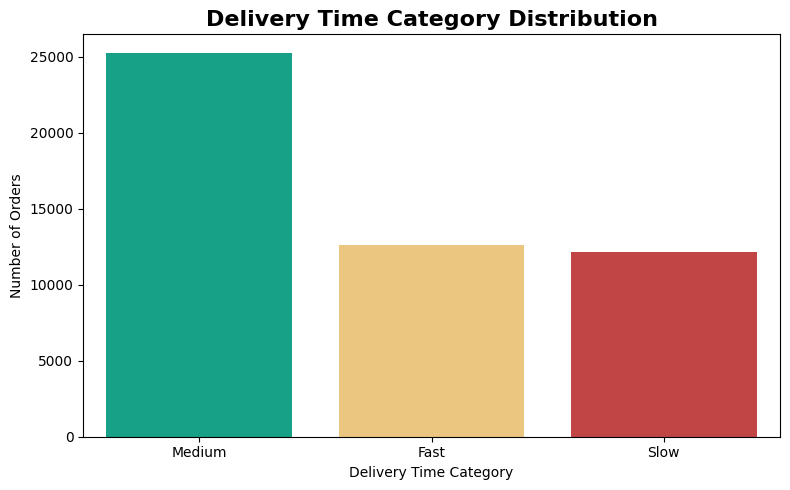


Features used:
['Order_Hour', 'Day_of_Week', 'Is_Weekend', 'Is_Festival', 'Weather', 'Pickup_Zone', 'Dropoff_Zone', 'Vehicle_Type', 'Rider_Experience_Years', 'Rider_Rating', 'Restaurant_Rating', 'Cuisine_Type', 'Order_Items', 'Restaurant_Load', 'Preparation_Time_Min', 'Road_Distance_km', 'Delivery_Distance_Category', 'Traffic_Level', 'Number_of_Signals', 'Average_Speed_kmph', 'Delivery_Priority', 'Order_Year', 'Order_Month', 'Order_Day']

X AND y SHAPE
X Shape: (50000, 24)
y Shape: (50000,)

LABEL ENCODING

Day_of_Week
{'Friday': np.int64(0), 'Monday': np.int64(1), 'Saturday': np.int64(2), 'Sunday': np.int64(3), 'Thursday': np.int64(4), 'Tuesday': np.int64(5), 'Wednesday': np.int64(6)}

Weather
{'Clear': np.int64(0), 'Cloudy': np.int64(1), 'Fog': np.int64(2), 'Rain': np.int64(3), 'Storm': np.int64(4)}

Pickup_Zone
{'CBD': np.int64(0), 'Commercial': np.int64(1), 'Industrial': np.int64(2), 'Residential': np.int64(3), 'Suburban': np.int64(4)}

Dropoff_Zone
{'CBD': np.int64(0), 'Commercia

,Model,Accuracy,Accuracy (%)
0,SVM,0.9504,95.04%
1,Logistic Regression,0.9472,94.72%
2,Gradient Boosting,0.9441,94.41%
3,Random Forest,0.9378,93.78%
4,Extra Trees,0.9207,92.07%
5,Decision Tree,0.9180,91.80%
6,KNN,0.7743,77.43%
7,Naive Bayes,0.3528,35.28%


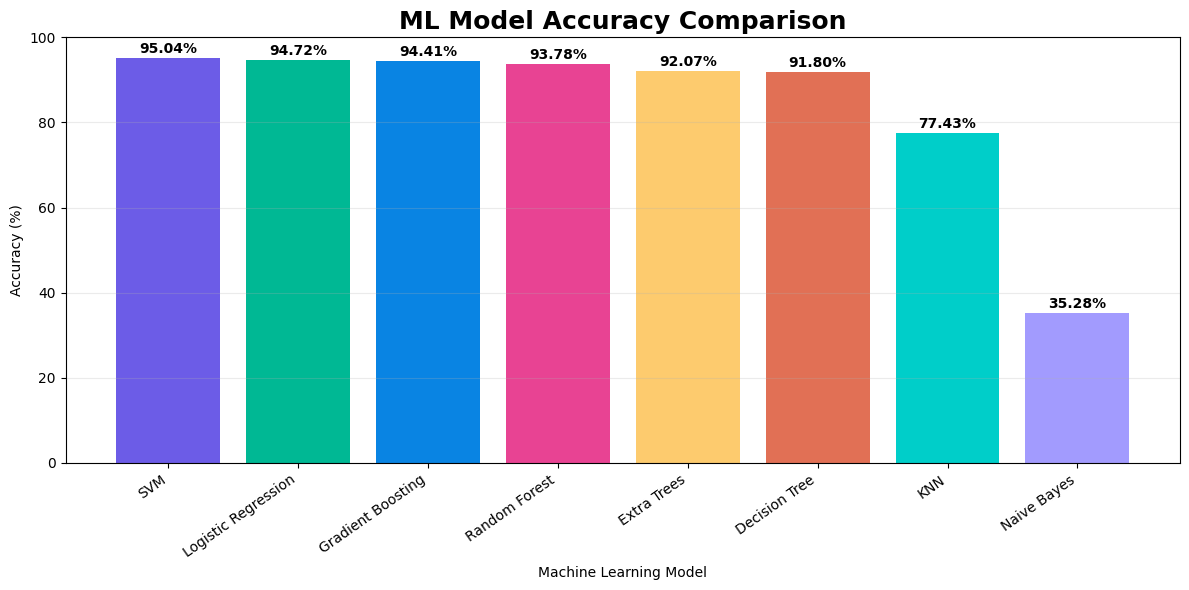


BEST MODEL
Best Model: SVM
Best Accuracy: 95.04%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Fast       0.94      0.94      0.94      2526
      Medium       0.95      0.95      0.95      5043
        Slow       0.97      0.95      0.96      2431

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



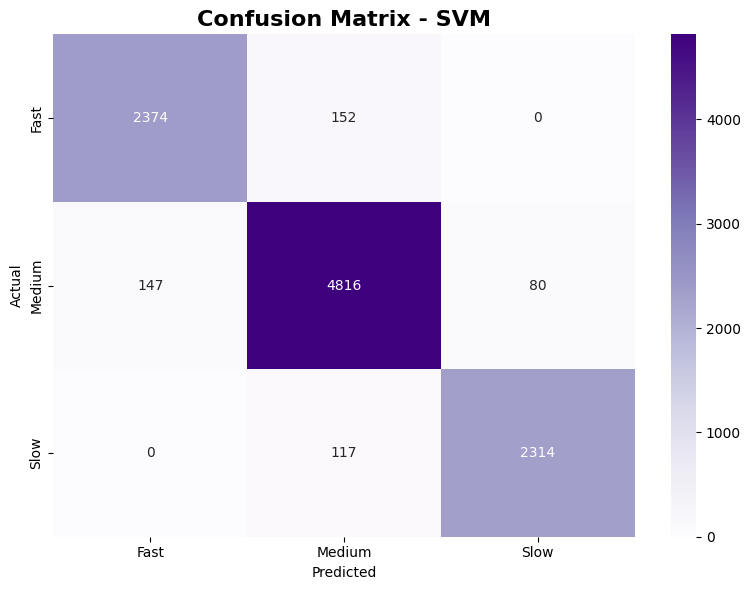


ACTUAL VS PREDICTED


,Actual,Predicted
0,Medium,Medium
1,Medium,Medium
2,Fast,Fast
3,Slow,Slow
4,Slow,Medium
5,Fast,Fast
6,Medium,Medium
7,Medium,Medium
8,Medium,Medium
9,Fast,Medium




FINAL ML SUMMARY
Total Records       : 50,000
Training Records    : 40,000
Testing Records     : 10,000
Number of Features  : 24
Number of Classes   : 3
Classes             : ['Fast', 'Medium', 'Slow']
Best Model          : SVM
Best Accuracy       : 95.04%


In [15]:
# Encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Train Test Split
from sklearn.model_selection import train_test_split

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)




print("=" * 80)
print("DATASET LOADED")
print("=" * 80)

print("Shape:", df.shape)

display(df.head())


# ==============================================================
# 3. CHECK COLUMNS
# ==============================================================

print("\nColumns:")
print(df.columns.tolist())


# ==============================================================
# 4. CHECK MISSING VALUES
# ==============================================================

print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)

print(df.isnull().sum())


# ==============================================================
# 5. REMOVE DUPLICATES
# ==============================================================

df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)


# ==============================================================
# 6. CONVERT DATE COLUMN
# ==============================================================

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)


# ==============================================================
# 7. CREATE DATE-BASED FEATURES
# ==============================================================

df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_Day"] = df["Order_Date"].dt.day


# ==============================================================
# 8. CREATE DELIVERY TIME CATEGORY
# ==============================================================

print("\n" + "=" * 80)
print("DELIVERY TIME STATISTICS")
print("=" * 80)

print(df["Time_taken_min"].describe())


# 25th and 75th percentile

q25 = df["Time_taken_min"].quantile(0.25)
q75 = df["Time_taken_min"].quantile(0.75)

print("\n25th Percentile:", q25)
print("75th Percentile:", q75)


# Create classification target

def delivery_category(time):

    if time <= q25:
        return "Fast"

    elif time <= q75:
        return "Medium"

    else:
        return "Slow"


df["Delivery_Time_Category"] = df["Time_taken_min"].apply(
    delivery_category
)


# ==============================================================
# 9. CHECK TARGET DISTRIBUTION
# ==============================================================

print("\n" + "=" * 80)
print("TARGET DISTRIBUTION")
print("=" * 80)

print(
    df["Delivery_Time_Category"].value_counts()
)


# Visualization

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Delivery_Time_Category",
    hue="Delivery_Time_Category",
    palette=["#00B894", "#FDCB6E", "#D63031"],
    legend=False
)

plt.title(
    "Delivery Time Category Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delivery Time Category")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


# ==============================================================
# 10. DEFINE FEATURES
# ==============================================================

features = [

    "Order_Hour",
    "Day_of_Week",
    "Is_Weekend",
    "Is_Festival",
    "Weather",

    "Pickup_Zone",
    "Dropoff_Zone",

    "Vehicle_Type",

    "Rider_Experience_Years",
    "Rider_Rating",
    "Restaurant_Rating",

    "Cuisine_Type",
    "Order_Items",
    "Restaurant_Load",

    "Preparation_Time_Min",
    "Road_Distance_km",

    "Delivery_Distance_Category",

    "Traffic_Level",
    "Number_of_Signals",

    "Average_Speed_kmph",
    "Delivery_Priority",

    "Order_Year",
    "Order_Month",
    "Order_Day"
]


# Keep only columns that exist

features = [
    col for col in features
    if col in df.columns
]


print("\nFeatures used:")
print(features)


# ==============================================================
# 11. CREATE X AND y
# ==============================================================

X = df[features].copy()

y = df["Delivery_Time_Category"].copy()


print("\n" + "=" * 80)
print("X AND y SHAPE")
print("=" * 80)

print("X Shape:", X.shape)
print("y Shape:", y.shape)


# ==============================================================
# 12. HANDLE MISSING VALUES
# ==============================================================

# Numerical columns

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns


for col in numeric_features:

    X[col] = X[col].fillna(
        X[col].median()
    )


# Categorical columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns


for col in categorical_features:

    X[col] = X[col].fillna(
        X[col].mode()[0]
    )


# ==============================================================
# 13. LABEL ENCODING
# ==============================================================

print("\n" + "=" * 80)
print("LABEL ENCODING")
print("=" * 80)

label_encoders = {}

for col in categorical_features:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = le

    print(f"\n{col}")

    print(
        dict(
            zip(
                le.classes_,
                le.transform(le.classes_)
            )
        )
    )


# ==============================================================
# 14. ENCODE TARGET
# ==============================================================

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(y)


print("\n" + "=" * 80)
print("TARGET ENCODING")
print("=" * 80)

print(
    dict(
        zip(
            target_encoder.classes_,
            target_encoder.transform(
                target_encoder.classes_
            )
        )
    )
)


# ==============================================================
# 15. TRAIN TEST SPLIT
# ==============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded
)


print("\n" + "=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ==============================================================
# 16. FEATURE SCALING
# ==============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ==============================================================
# 17. DEFINE ML MODELS
# ==============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Naive Bayes":
        GaussianNB(),

    "SVM":
        SVC(
            kernel="rbf"
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}


# ==============================================================
# 18. TRAIN ALL MODELS
# ==============================================================

results = []

trained_models = {}

print("\n" + "=" * 80)
print("MODEL TRAINING")
print("=" * 80)


for name, model in models.items():

    print(f"\nTraining: {name}")

    # Models that benefit from scaling
    if name in [
        "Logistic Regression",
        "KNN",
        "SVM"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

        prediction = model.predict(
            X_test_scaled
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        prediction = model.predict(
            X_test
        )


    accuracy = accuracy_score(
        y_test,
        prediction
    )

    accuracy_percentage = accuracy * 100


    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Accuracy (%)":
            accuracy_percentage

    })


    trained_models[name] = model


    print(
        f"{name} Accuracy: "
        f"{accuracy_percentage:.2f}%"
    )


# ==============================================================
# 19. MODEL COMPARISON
# ==============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 80)
print("MODEL ACCURACY COMPARISON")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Accuracy (%)": "{:.2f}%"
    })
)


# ==============================================================
# 20. ACCURACY VISUALIZATION
# ==============================================================

plt.figure(figsize=(12, 6))

bars = plt.bar(

    results_df["Model"],

    results_df["Accuracy (%)"],

    color=[
        "#6C5CE7",
        "#00B894",
        "#0984E3",
        "#E84393",
        "#FDCB6E",
        "#E17055",
        "#00CEC9",
        "#A29BFE"
    ][:len(results_df)]

)


plt.title(
    "ML Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.xticks(
    rotation=35,
    ha="right"
)


# Add percentage on bars

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() +
        bar.get_width() / 2,

        height + 0.5,

        f"{height:.2f}%",

        ha="center",

        va="bottom",

        fontsize=10,

        fontweight="bold"

    )


plt.ylim(
    0,
    min(100, results_df["Accuracy (%)"].max() + 10)
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ==============================================================
# 21. BEST MODEL
# ==============================================================

best_model_name = results_df.iloc[0]["Model"]

best_accuracy = results_df.iloc[0]["Accuracy (%)"]


print("\n" + "=" * 80)
print("BEST MODEL")
print("=" * 80)

print("Best Model:", best_model_name)

print(
    f"Best Accuracy: {best_accuracy:.2f}%"
)


# ==============================================================
# 22. BEST MODEL PREDICTIONS
# ==============================================================

best_model = trained_models[
    best_model_name
]


if best_model_name in [
    "Logistic Regression",
    "KNN",
    "SVM"
]:

    best_predictions = best_model.predict(
        X_test_scaled
    )

else:

    best_predictions = best_model.predict(
        X_test
    )


# ==============================================================
# 23. CLASSIFICATION REPORT
# ==============================================================

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(

        y_test,

        best_predictions,

        target_names=
        target_encoder.classes_

    )
)


# ==============================================================
# 24. CONFUSION MATRIX
# ==============================================================

cm = confusion_matrix(
    y_test,
    best_predictions
)


plt.figure(figsize=(8, 6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Purples",

    xticklabels=
    target_encoder.classes_,

    yticklabels=
    target_encoder.classes_

)


plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.show()


# ==============================================================
# 25. ACTUAL VS PREDICTED
# ==============================================================

actual_labels = target_encoder.inverse_transform(
    y_test
)

predicted_labels = target_encoder.inverse_transform(
    best_predictions
)


comparison = pd.DataFrame({

    "Actual": actual_labels,

    "Predicted": predicted_labels

})


print("\n" + "=" * 80)
print("ACTUAL VS PREDICTED")
print("=" * 80)

display(
    comparison.head(20)
)


# ==============================================================
# 26. FEATURE IMPORTANCE
# ==============================================================

if hasattr(
    best_model,
    "feature_importances_"
):

    importance = pd.DataFrame({

        "Feature":
            X.columns,

        "Importance":
            best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )


    print("\n" + "=" * 80)
    print("FEATURE IMPORTANCE")
    print("=" * 80)

    display(
        importance.head(15)
    )


    # Visualization

    plt.figure(figsize=(11, 7))

    sns.barplot(

        data=importance.head(15),

        x="Importance",

        y="Feature",

        hue="Feature",

        palette="viridis",

        legend=False

    )

    plt.title(
        f"Top 15 Important Features - {best_model_name}",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel("Importance")

    plt.ylabel("Feature")

    plt.tight_layout()

    plt.show()


# ==============================================================
# 27. FINAL SUMMARY
# ==============================================================

print("\n")
print("=" * 80)
print("FINAL ML SUMMARY")
print("=" * 80)

print(
    f"Total Records       : {len(df):,}"
)

print(
    f"Training Records    : {len(X_train):,}"
)

print(
    f"Testing Records     : {len(X_test):,}"
)

print(
    f"Number of Features  : {X.shape[1]}"
)

print(
    f"Number of Classes   : {len(target_encoder.classes_)}"
)

print(
    f"Classes             : "
    f"{list(target_encoder.classes_)}"
)

print(
    f"Best Model          : {best_model_name}"
)

print(
    f"Best Accuracy       : "
    f"{best_accuracy:.2f}%"
)

print("=" * 80)

## Thank you..pls upvote!!!!!!!!!